### Raw data statistics

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

raw_df = pd.read_csv('../data/raw/SPY.csv')

print( f"Raw data shape: {raw_df.shape}" )
raw_df.head()

Raw data shape: (4023, 8)


,date,close,high,low,open,volume,tic,day
0,2010-01-04,84.796371,84.841263,83.434602,84.078076,118944600,SPY,0
1,2010-01-05,85.020821,85.058234,84.437206,84.743981,111579900,SPY,1
2,2010-01-06,85.080696,85.290198,84.871194,84.938531,116074400,SPY,2
3,2010-01-07,85.439835,85.544586,84.684126,84.923557,131091100,SPY,3
4,2010-01-08,85.724182,85.761596,85.043300,85.215389,126402800,SPY,4


#### Seasonal Volume Patterns

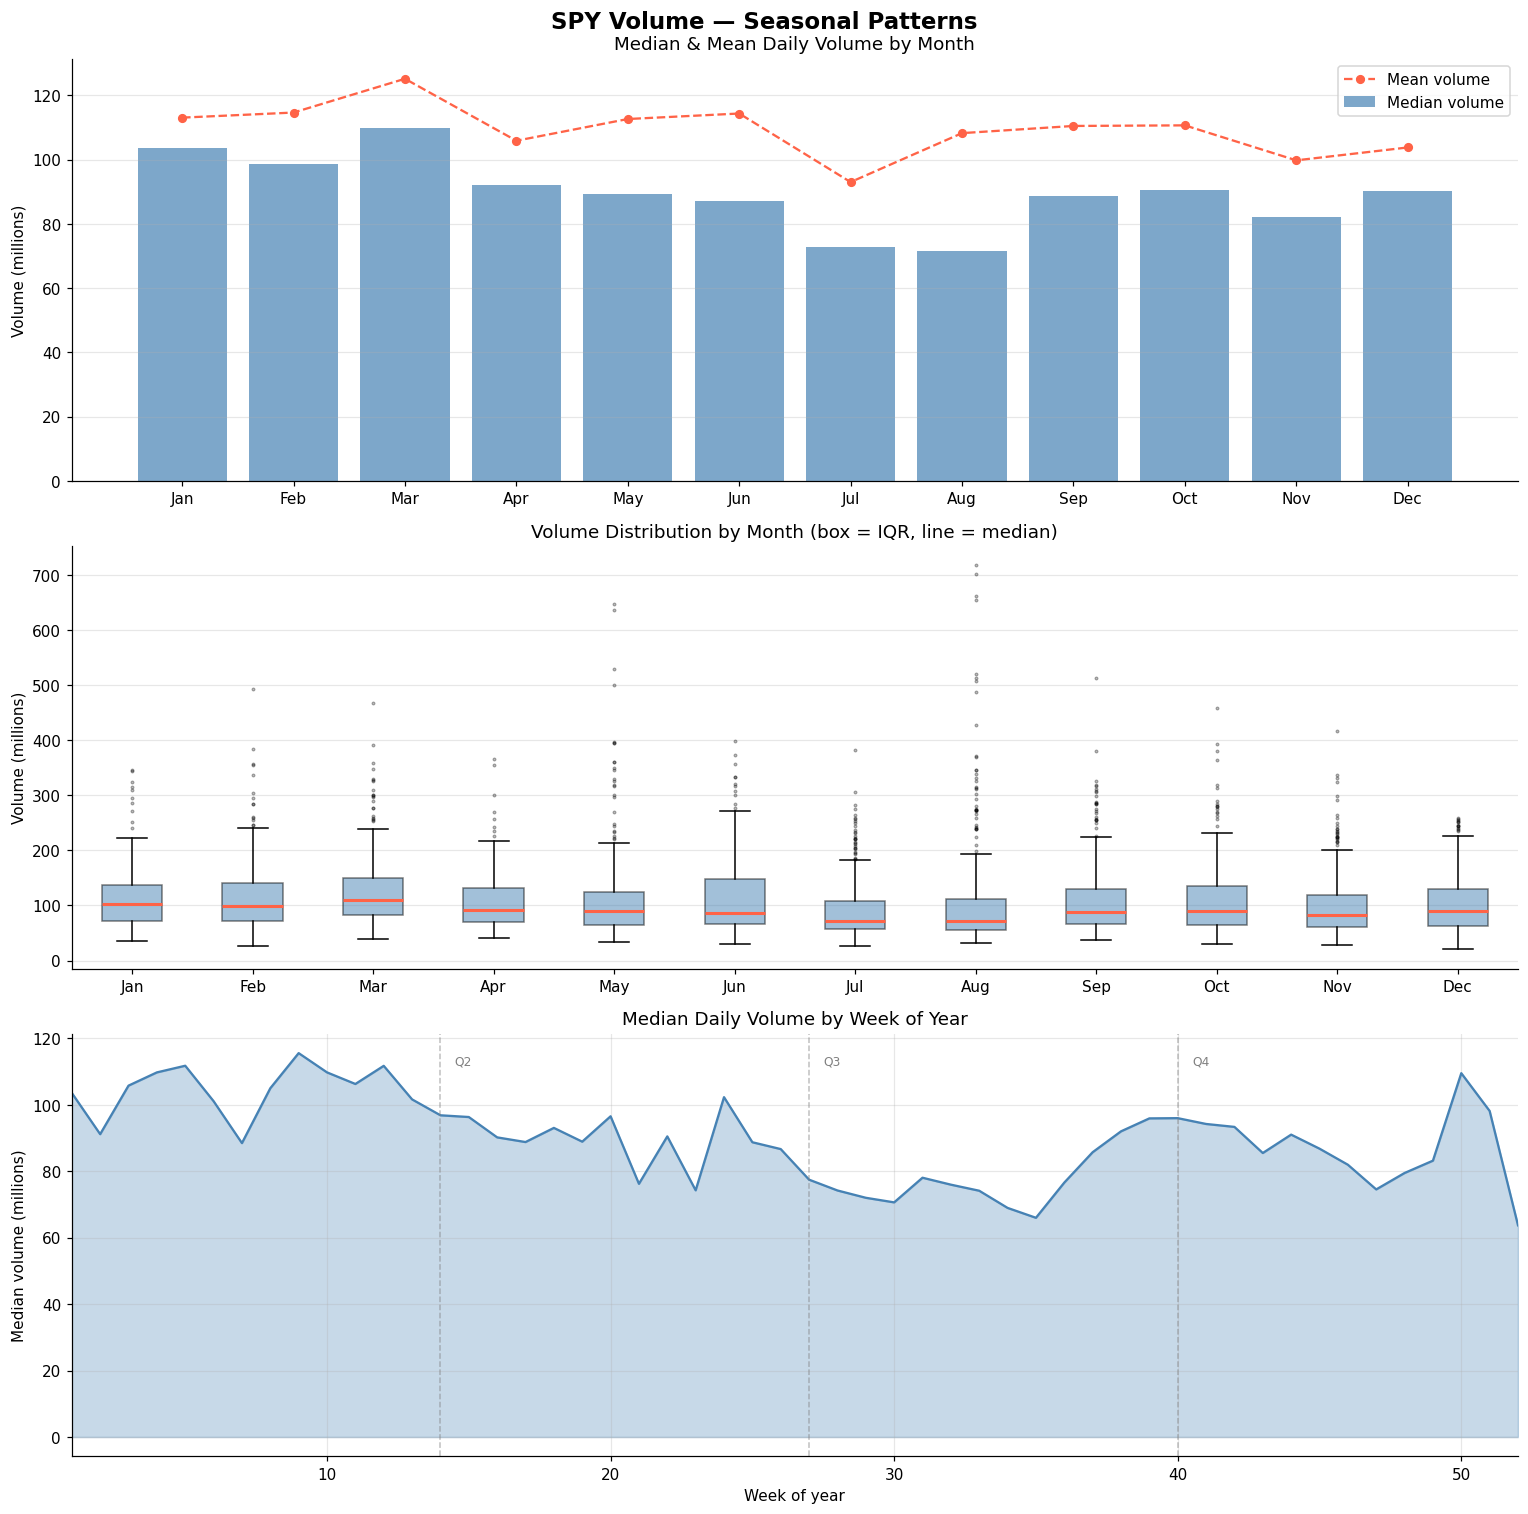

In [28]:
df = raw_df.copy()
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month
df['month_name'] = df['date'].dt.strftime('%b')
df['week'] = df['date'].dt.isocalendar().week.astype(int)
df['quarter'] = df['date'].dt.quarter

month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(3, 1, figsize=(14, 14))
fig.suptitle('SPY Volume — Seasonal Patterns', fontsize=15, fontweight='bold', y=0.98)

# --- 1. Monthly median volume (bar) + distribution (box overlay) ---
ax = axes[0]
monthly = df.groupby('month_name')['volume']
medians = monthly.median().reindex(month_order)
means   = monthly.mean().reindex(month_order)

x = np.arange(len(month_order))
bars = ax.bar(x, medians / 1e6, color='steelblue', alpha=0.7, label='Median volume')
ax.plot(x, means / 1e6, 'o--', color='tomato', linewidth=1.5, markersize=5, label='Mean volume')
ax.set_xticks(x)
ax.set_xticklabels(month_order)
ax.set_ylabel('Volume (millions)')
ax.set_title('Median & Mean Daily Volume by Month')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# --- 2. Box plot by month to show spread ---
ax = axes[1]
data_by_month = [df[df['month_name'] == m]['volume'].values / 1e6 for m in month_order]
bp = ax.boxplot(data_by_month, labels=month_order, patch_artist=True,
                medianprops=dict(color='tomato', linewidth=2),
                flierprops=dict(marker='.', markersize=3, alpha=0.4))
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.5)
ax.set_ylabel('Volume (millions)')
ax.set_title('Volume Distribution by Month (box = IQR, line = median)')
ax.grid(axis='y', alpha=0.3)

# --- 3. Weekly median volume (heatmap-style line, week 1–52) ---
ax = axes[2]
weekly_med = df.groupby('week')['volume'].median() / 1e6
weekly_med = weekly_med.reindex(range(1, 53))
ax.fill_between(weekly_med.index, weekly_med.values, alpha=0.3, color='steelblue')
ax.plot(weekly_med.index, weekly_med.values, color='steelblue', linewidth=1.5)

# Quarter boundaries
for q_week in [14, 27, 40]:
    ax.axvline(q_week, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.text(q_week + 0.5, weekly_med.max() * 0.97, f'Q{q_week//13 + 1}', fontsize=8, color='gray')

ax.set_xlabel('Week of year')
ax.set_ylabel('Median volume (millions)')
ax.set_title('Median Daily Volume by Week of Year')
ax.set_xlim(1, 52)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

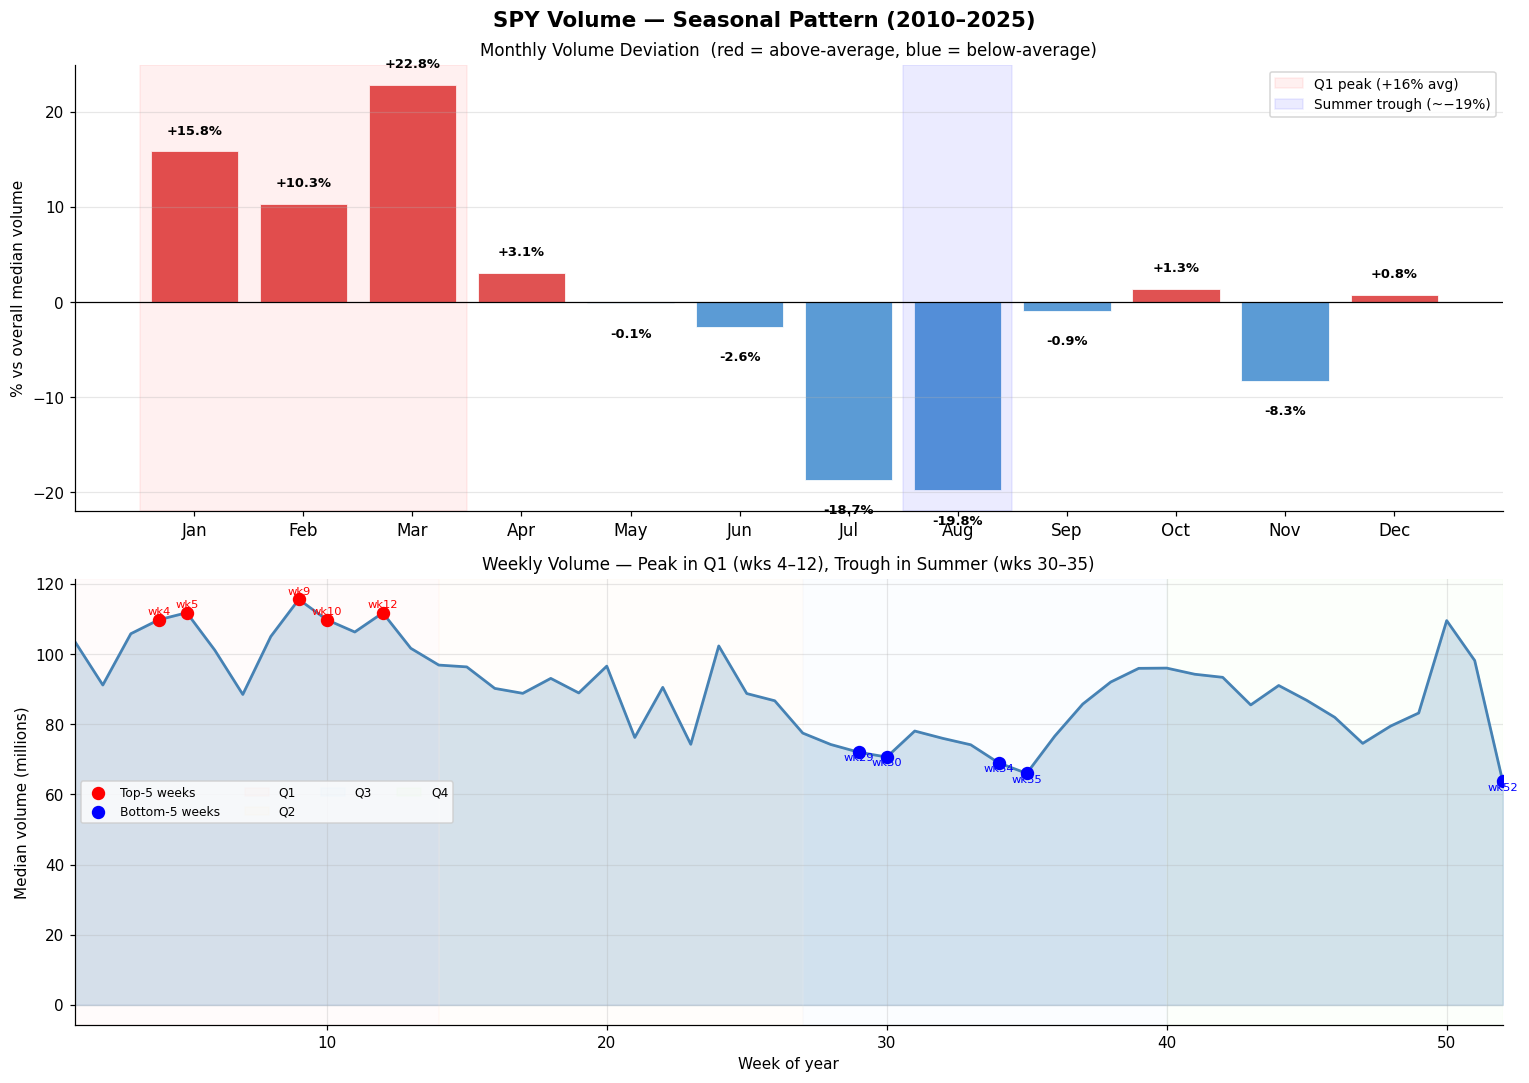

Seasonal pattern summary (% vs overall median):
  Jan: +15.8%  +███████
  Feb: +10.3%  +█████
  Mar: +22.8%  +███████████
  Apr:  +3.1%  +█
  May:  -0.1%  -
  Jun:  -2.6%  -█
  Jul: -18.7%  -█████████
  Aug: -19.8%  -█████████
  Sep:  -0.9%  -
  Oct:  +1.3%  +
  Nov:  -8.3%  -████
  Dec:  +0.8%  +


In [29]:
monthly_med = df.groupby('month_name')['volume'].median().reindex(month_order)
overall_med = df['volume'].median()
pct = (monthly_med / overall_med - 1) * 100

weekly_med = df.groupby('week')['volume'].median().reindex(range(1, 53))

# ── colour each bar by direction ──────────────────────────────────────────────
colors_m = ['#e05252' if v > 0 else '#5b9bd5' for v in pct]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('SPY Volume — Seasonal Pattern (2010–2025)', fontsize=14, fontweight='bold')

# ── Panel 1 : monthly deviation from median ───────────────────────────────────
ax = axes[0]
bars = ax.bar(range(12), pct, color=colors_m, edgecolor='white', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(range(12))
ax.set_xticklabels(month_order, fontsize=11)
ax.set_ylabel('% vs overall median volume', fontsize=10)
ax.set_title('Monthly Volume Deviation  (red = above-average, blue = below-average)', fontsize=11)
ax.grid(axis='y', alpha=0.3)

# annotate each bar
for i, (bar, v) in enumerate(zip(bars, pct)):
    ax.text(bar.get_x() + bar.get_width()/2, v + (1.5 if v >= 0 else -2.5),
            f'{v:+.1f}%', ha='center', va='bottom' if v >= 0 else 'top',
            fontsize=8.5, fontweight='bold')

# add region labels
ax.axvspan(-0.5, 2.5, alpha=0.06, color='red', label='Q1 peak (+16% avg)')
ax.axvspan(6.5, 7.5, alpha=0.08, color='blue', label='Summer trough (~−19%)')
ax.legend(fontsize=9)

# ── Panel 2 : week-of-year line ───────────────────────────────────────────────
ax = axes[1]
ax.fill_between(weekly_med.index, weekly_med / 1e6, alpha=0.25, color='steelblue')
ax.plot(weekly_med.index, weekly_med / 1e6, color='steelblue', linewidth=1.8)

# mark top-5 and bottom-5 weeks
high_weeks = weekly_med.nlargest(5)
low_weeks  = weekly_med.nsmallest(5)
ax.scatter(high_weeks.index, high_weeks / 1e6, color='red',   zorder=5, s=60, label='Top-5 weeks')
ax.scatter(low_weeks.index,  low_weeks  / 1e6, color='blue',  zorder=5, s=60, label='Bottom-5 weeks')
for w, v in high_weeks.items():
    ax.text(w, v/1e6 + 1.5, f'wk{w}', ha='center', fontsize=7.5, color='red')
for w, v in low_weeks.items():
    ax.text(w, v/1e6 - 2.5, f'wk{w}', ha='center', fontsize=7.5, color='blue')

# quarter shading
q_starts = [1, 14, 27, 40, 52]
q_colors = ['#ffe0e0','#fff4e0','#e0f0ff','#e8ffe0']
for i in range(4):
    ax.axvspan(q_starts[i], q_starts[i+1], alpha=0.12, color=q_colors[i], label=f'Q{i+1}')

ax.set_xlabel('Week of year', fontsize=10)
ax.set_ylabel('Median volume (millions)', fontsize=10)
ax.set_title('Weekly Volume — Peak in Q1 (wks 4–12), Trough in Summer (wks 30–35)', fontsize=11)
ax.set_xlim(1, 52)
ax.grid(alpha=0.3)
ax.legend(fontsize=8, ncol=4)

plt.tight_layout()
plt.show()

# ── Print summary ─────────────────────────────────────────────────────────────
print("Seasonal pattern summary (% vs overall median):")
for m, v in zip(month_order, pct):
    bar = '█' * int(abs(v) // 2)
    sign = '+' if v > 0 else '-'
    print(f"  {m:>3}: {v:+5.1f}%  {sign}{bar}")

---
## 1 — Raw Data Overview

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

raw = pd.read_csv('../data/raw/SPY.csv', parse_dates=['date'])
raw = raw.sort_values('date').reset_index(drop=True)

print(f"Shape          : {raw.shape}")
print(f"Date range     : {raw['date'].min().date()}  →  {raw['date'].max().date()}")
print(f"Trading days   : {len(raw):,}  (~{len(raw)/252:.1f} years)")
print(f"\nNull counts:\n{raw.isnull().sum().to_string()}")
print()
raw.describe().round(2)

Shape          : (4023, 8)
Date range     : 2010-01-04  →  2025-12-30
Trading days   : 4,023  (~16.0 years)

Null counts:
date      0
close     0
high      0
low       0
open      0
volume    0
tic       0
day       0



,date,close,high,low,open,volume,day
count,4023,4023.00,4023.00,4023.00,4023.00,4.023000e+03,4023.00
mean,2017-12-29 19:36:54.765100544,267.97,269.36,266.35,267.92,1.093688e+08,2.02
min,2010-01-04 00:00:00,77.15,78.07,76.34,77.84,2.027000e+07,0.00
25%,2014-01-01 00:00:00,146.22,146.67,145.84,146.32,6.523535e+07,1.00
50%,2017-12-28 00:00:00,227.70,230.95,226.07,227.96,8.943310e+07,2.00
75%,2021-12-27 12:00:00,386.30,388.48,383.57,385.72,1.328858e+08,3.00
max,2025-12-30 00:00:00,688.50,689.78,687.39,688.76,7.178287e+08,4.00
std,NaN,155.48,156.25,154.57,155.46,6.797125e+07,1.40


---
## 2 — Price & Volume History

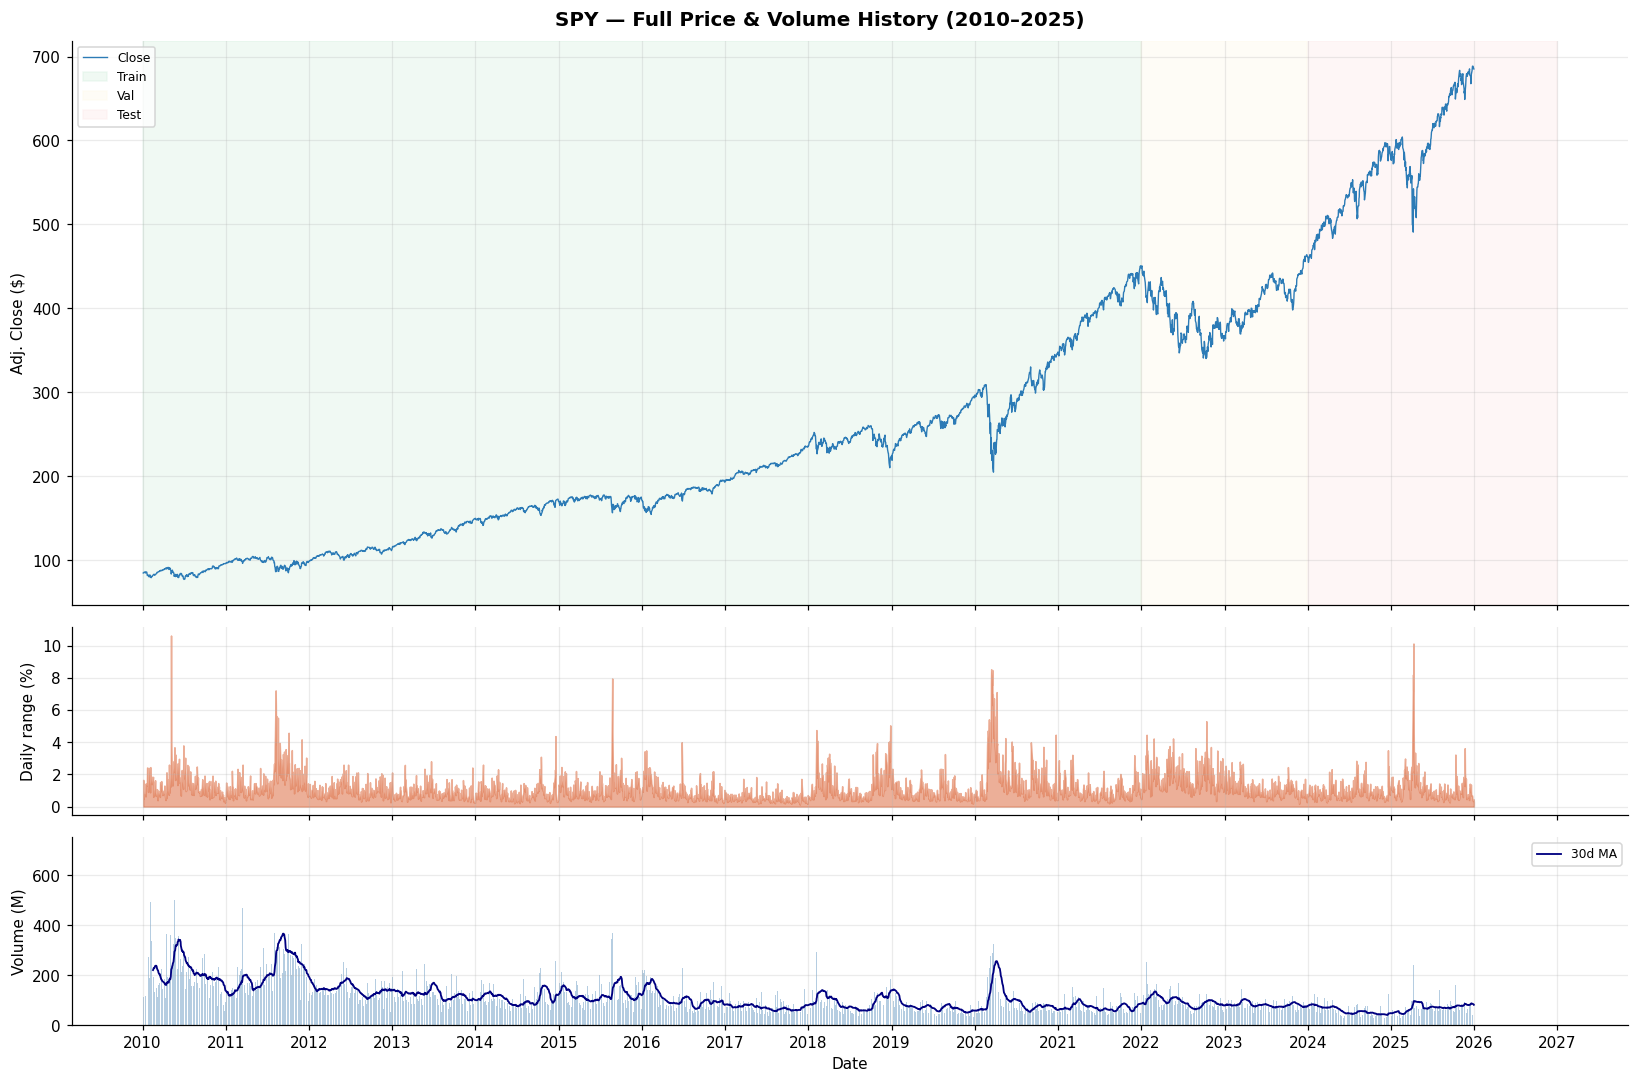

In [31]:
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1, 1]})
fig.suptitle('SPY — Full Price & Volume History (2010–2025)', fontsize=13, fontweight='bold')

# 1. Close price with train/val/test shading
ax = axes[0]
ax.plot(raw['date'], raw['close'], linewidth=0.9, color='#2c7bb6', label='Close')
for name, s, e, c in [('Train','2010-01-01','2021-12-31','#d4efdf'),
                       ('Val',  '2022-01-01','2023-12-31','#fef9e7'),
                       ('Test', '2024-01-01','2026-12-31','#fde8e8')]:
    ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.35, color=c, label=name)
ax.set_ylabel('Adj. Close ($)')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.25)

# 2. Daily range %
ax = axes[1]
rng = (raw['high'] - raw['low']) / raw['close'] * 100
ax.fill_between(raw['date'], rng, alpha=0.6, color='#e07b54')
ax.set_ylabel('Daily range (%)')
ax.grid(alpha=0.25)

# 3. Volume with 30d MA
ax = axes[2]
ax.bar(raw['date'], raw['volume'] / 1e6, width=1, color='steelblue', alpha=0.4)
ax.plot(raw['date'], raw['volume'].rolling(30).mean() / 1e6,
        color='navy', linewidth=1.2, label='30d MA')
ax.set_ylabel('Volume (M)')
ax.set_xlabel('Date')
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.autofmt_xdate(rotation=0, ha='center')
plt.tight_layout()
plt.show()

---
## 3 — Return Distribution Analysis

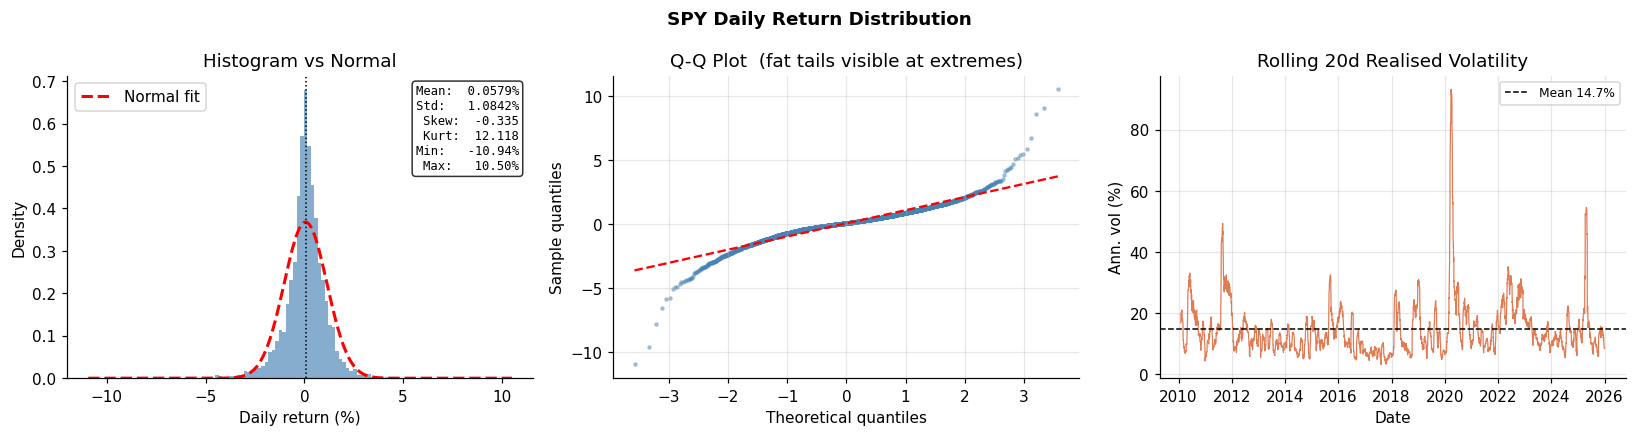

Excess kurtosis: 12.12  (normal = 0, heavy tails > 0)
Jarque-Bera p  : 0.00e+00  → NOT normal


In [32]:
ret = raw['close'].pct_change().dropna() * 100   # daily % return

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('SPY Daily Return Distribution', fontsize=12, fontweight='bold')

# Histogram + normal fit
ax = axes[0]
ax.hist(ret, bins=120, density=True, color='steelblue', alpha=0.65, edgecolor='none')
xr = np.linspace(ret.min(), ret.max(), 300)
ax.plot(xr, stats.norm.pdf(xr, ret.mean(), ret.std()), 'r--', lw=2, label='Normal fit')
ax.axvline(ret.mean(), color='black', lw=1, linestyle=':')
ax.set_xlabel('Daily return (%)')
ax.set_ylabel('Density')
ax.set_title('Histogram vs Normal')
ax.legend()
ax.text(0.97, 0.97,
        f"Mean:  {ret.mean():.4f}%\nStd:   {ret.std():.4f}%\n"
        f"Skew:  {ret.skew():.3f}\nKurt:  {ret.kurtosis():.3f}\n"
        f"Min:   {ret.min():.2f}%\nMax:   {ret.max():.2f}%",
        transform=ax.transAxes, fontsize=8, va='top', ha='right', family='monospace',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# QQ-plot
ax = axes[1]
(osm, osr), (slope, intercept, _) = stats.probplot(ret, dist='norm')
ax.scatter(osm, osr, s=4, alpha=0.4, color='steelblue')
ax.plot(osm, slope * np.array(osm) + intercept, 'r--', lw=1.5)
ax.set_xlabel('Theoretical quantiles')
ax.set_ylabel('Sample quantiles')
ax.set_title('Q-Q Plot  (fat tails visible at extremes)')
ax.grid(alpha=0.3)

# Rolling 20d annualised vol
ax = axes[2]
roll_vol = ret.rolling(20).std() * np.sqrt(252)
ax.plot(raw['date'].iloc[1:], roll_vol, color='#e07b54', linewidth=0.8)
ax.axhline(roll_vol.mean(), color='black', lw=1, linestyle='--',
           label=f'Mean {roll_vol.mean():.1f}%')
ax.set_xlabel('Date')
ax.set_ylabel('Ann. vol (%)')
ax.set_title('Rolling 20d Realised Volatility')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

jb_stat, jb_p = stats.jarque_bera(ret)
print(f"Excess kurtosis: {ret.kurtosis():.2f}  (normal = 0, heavy tails > 0)")
print(f"Jarque-Bera p  : {jb_p:.2e}  → {'NOT normal' if jb_p < 0.05 else 'normal'}")

---
## 4 — Feature Engineering
Compute all 15 model features on the raw data (pre-normalisation) for inspection.

In [33]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import ta

df = raw.copy()

# Group 1: Price / return
df['ret_1d']    = df['close'].pct_change(1) * 100
df['ret_5d']    = df['close'].pct_change(5) * 100
sma20           = df['close'].rolling(20).mean()
df['sma_ratio'] = df['close'] / sma20
df['vol_20d']   = df['ret_1d'].rolling(20).std()
df['vol_ratio'] = df['volume'] / df['volume'].rolling(20).mean()

# Group 2: Momentum
df['rsi_14'] = ta.momentum.RSIIndicator(df['close'], window=14).rsi()
macd = ta.trend.MACD(df['close'], window_slow=26, window_fast=12, window_sign=9)
df['macd_hist'] = macd.macd_diff() / df['close'] * 1e4   # ×10k for readability
stoch = ta.momentum.StochasticOscillator(df['high'], df['low'], df['close'], window=14)
df['stoch_k'] = stoch.stoch()
df['stoch_d'] = stoch.stoch_signal()

# Group 3: Volatility / bands
bb = ta.volatility.BollingerBands(df['close'], window=20, window_dev=2)
df['bb_width'] = bb.bollinger_wband() * 100
df['bb_pct']   = bb.bollinger_pband() * 100

# Group 4: Volume
obv = ta.volume.OnBalanceVolumeIndicator(df['close'], df['volume']).on_balance_volume()
df['obv_ret'] = obv.pct_change(1).replace([np.inf, -np.inf], np.nan) * 100

# Group 5: Trend
adx_ind          = ta.trend.ADXIndicator(df['high'], df['low'], df['close'], window=14)
df['adx']        = adx_ind.adx()
df['adx_di_diff']= adx_ind.adx_pos() - adx_ind.adx_neg()
psar             = ta.trend.PSARIndicator(df['high'], df['low'], df['close'])
df['psar_bull']  = psar.psar_up().notna().astype(float)

FEAT_COLS = ['ret_1d','ret_5d','sma_ratio','vol_20d','vol_ratio',
             'rsi_14','macd_hist','stoch_k','stoch_d',
             'bb_width','bb_pct','obv_ret','adx','adx_di_diff','psar_bull']

df = df.dropna(subset=FEAT_COLS).reset_index(drop=True)
print(f"Rows after warmup drop: {len(df):,}  (lost {len(raw)-len(df)} warmup rows)")
print()
df[FEAT_COLS].describe().round(3)

Rows after warmup drop: 3,990  (lost 33 warmup rows)



,ret_1d,ret_5d,sma_ratio,vol_20d,vol_ratio,rsi_14,macd_hist,stoch_k,stoch_d,bb_width,bb_pct,obv_ret,adx,adx_di_diff,psar_bull
count,3990.000,3990.000,3990.000,3990.000,3990.000,3990.000,3990.000,3990.000,3990.000,3990.000,3990.000,3990.000,3990.000,3990.000,3990.000
mean,0.059,0.292,1.005,0.925,1.006,56.360,0.071,65.851,65.855,610.525,61.642,5.434,22.882,2.529,0.630
std,1.084,2.243,0.024,0.581,0.346,11.367,34.193,30.203,27.872,389.167,32.132,351.142,7.895,13.461,0.483
min,-10.942,-17.969,0.799,0.201,0.304,16.803,-255.710,0.000,0.851,94.541,-47.308,-2170.579,9.063,-56.278,0.000
25%,-0.369,-0.690,0.995,0.578,0.776,48.476,-15.119,43.242,43.796,375.648,39.711,-0.972,16.805,-6.386,0.000
50%,0.070,0.466,1.009,0.775,0.939,57.718,0.736,75.708,75.907,520.972,71.043,0.434,21.542,3.881,1.000
75%,0.579,1.492,1.019,1.094,1.150,64.879,17.164,92.458,90.390,729.671,86.350,0.980,27.814,12.459,1.000
max,10.502,17.358,1.115,5.870,3.557,87.192,214.495,100.000,99.938,4326.984,129.242,18293.195,55.202,40.858,1.000


---
## 5 — Feature Distributions (all 15)

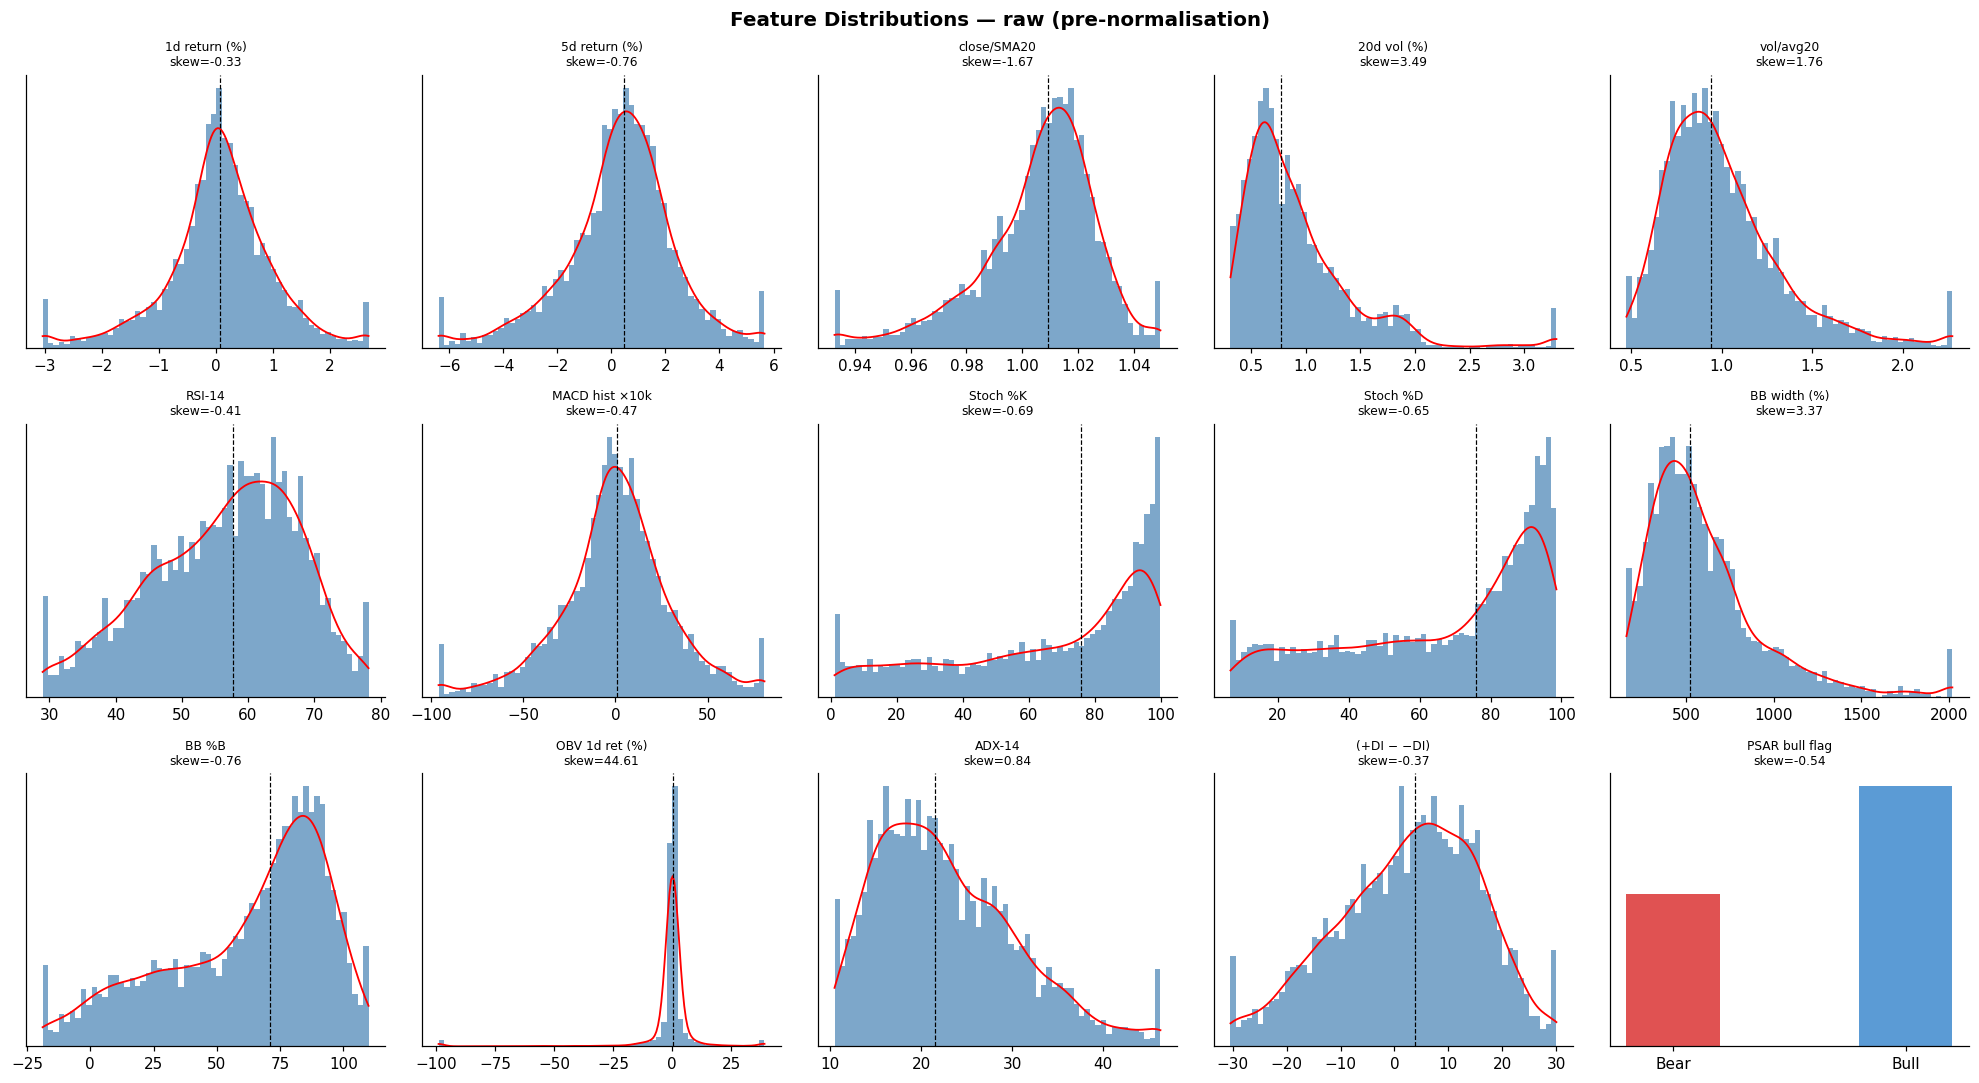

In [34]:
LABELS = {
    'ret_1d':'1d return (%)', 'ret_5d':'5d return (%)',
    'sma_ratio':'close/SMA20', 'vol_20d':'20d vol (%)',
    'vol_ratio':'vol/avg20', 'rsi_14':'RSI-14',
    'macd_hist':'MACD hist ×10k', 'stoch_k':'Stoch %K',
    'stoch_d':'Stoch %D', 'bb_width':'BB width (%)',
    'bb_pct':'BB %B', 'obv_ret':'OBV 1d ret (%)',
    'adx':'ADX-14', 'adx_di_diff':'(+DI − −DI)',
    'psar_bull':'PSAR bull flag',
}

fig, axes = plt.subplots(3, 5, figsize=(18, 10))
fig.suptitle('Feature Distributions — raw (pre-normalisation)', fontsize=13, fontweight='bold')

for ax, col in zip(axes.flat, FEAT_COLS):
    data = df[col].dropna()
    if col == 'psar_bull':
        cnts = data.value_counts().sort_index()
        ax.bar(cnts.index, cnts.values, color=['#e05252','#5b9bd5'], width=0.4)
        ax.set_xticks([0,1]); ax.set_xticklabels(['Bear','Bull'])
    else:
        lo, hi = data.quantile(0.01), data.quantile(0.99)
        ax.hist(data.clip(lo, hi), bins=60, density=True,
                color='steelblue', alpha=0.7, edgecolor='none')
        kde_x = np.linspace(lo, hi, 200)
        kde   = stats.gaussian_kde(data.clip(lo, hi))(kde_x)
        ax.plot(kde_x, kde, 'r-', linewidth=1.2)
        ax.axvline(data.median(), color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f"{LABELS[col]}\nskew={data.skew():.2f}", fontsize=8)
    ax.set_yticks([])

plt.tight_layout()
plt.show()

---
## 6 — Feature Time Series

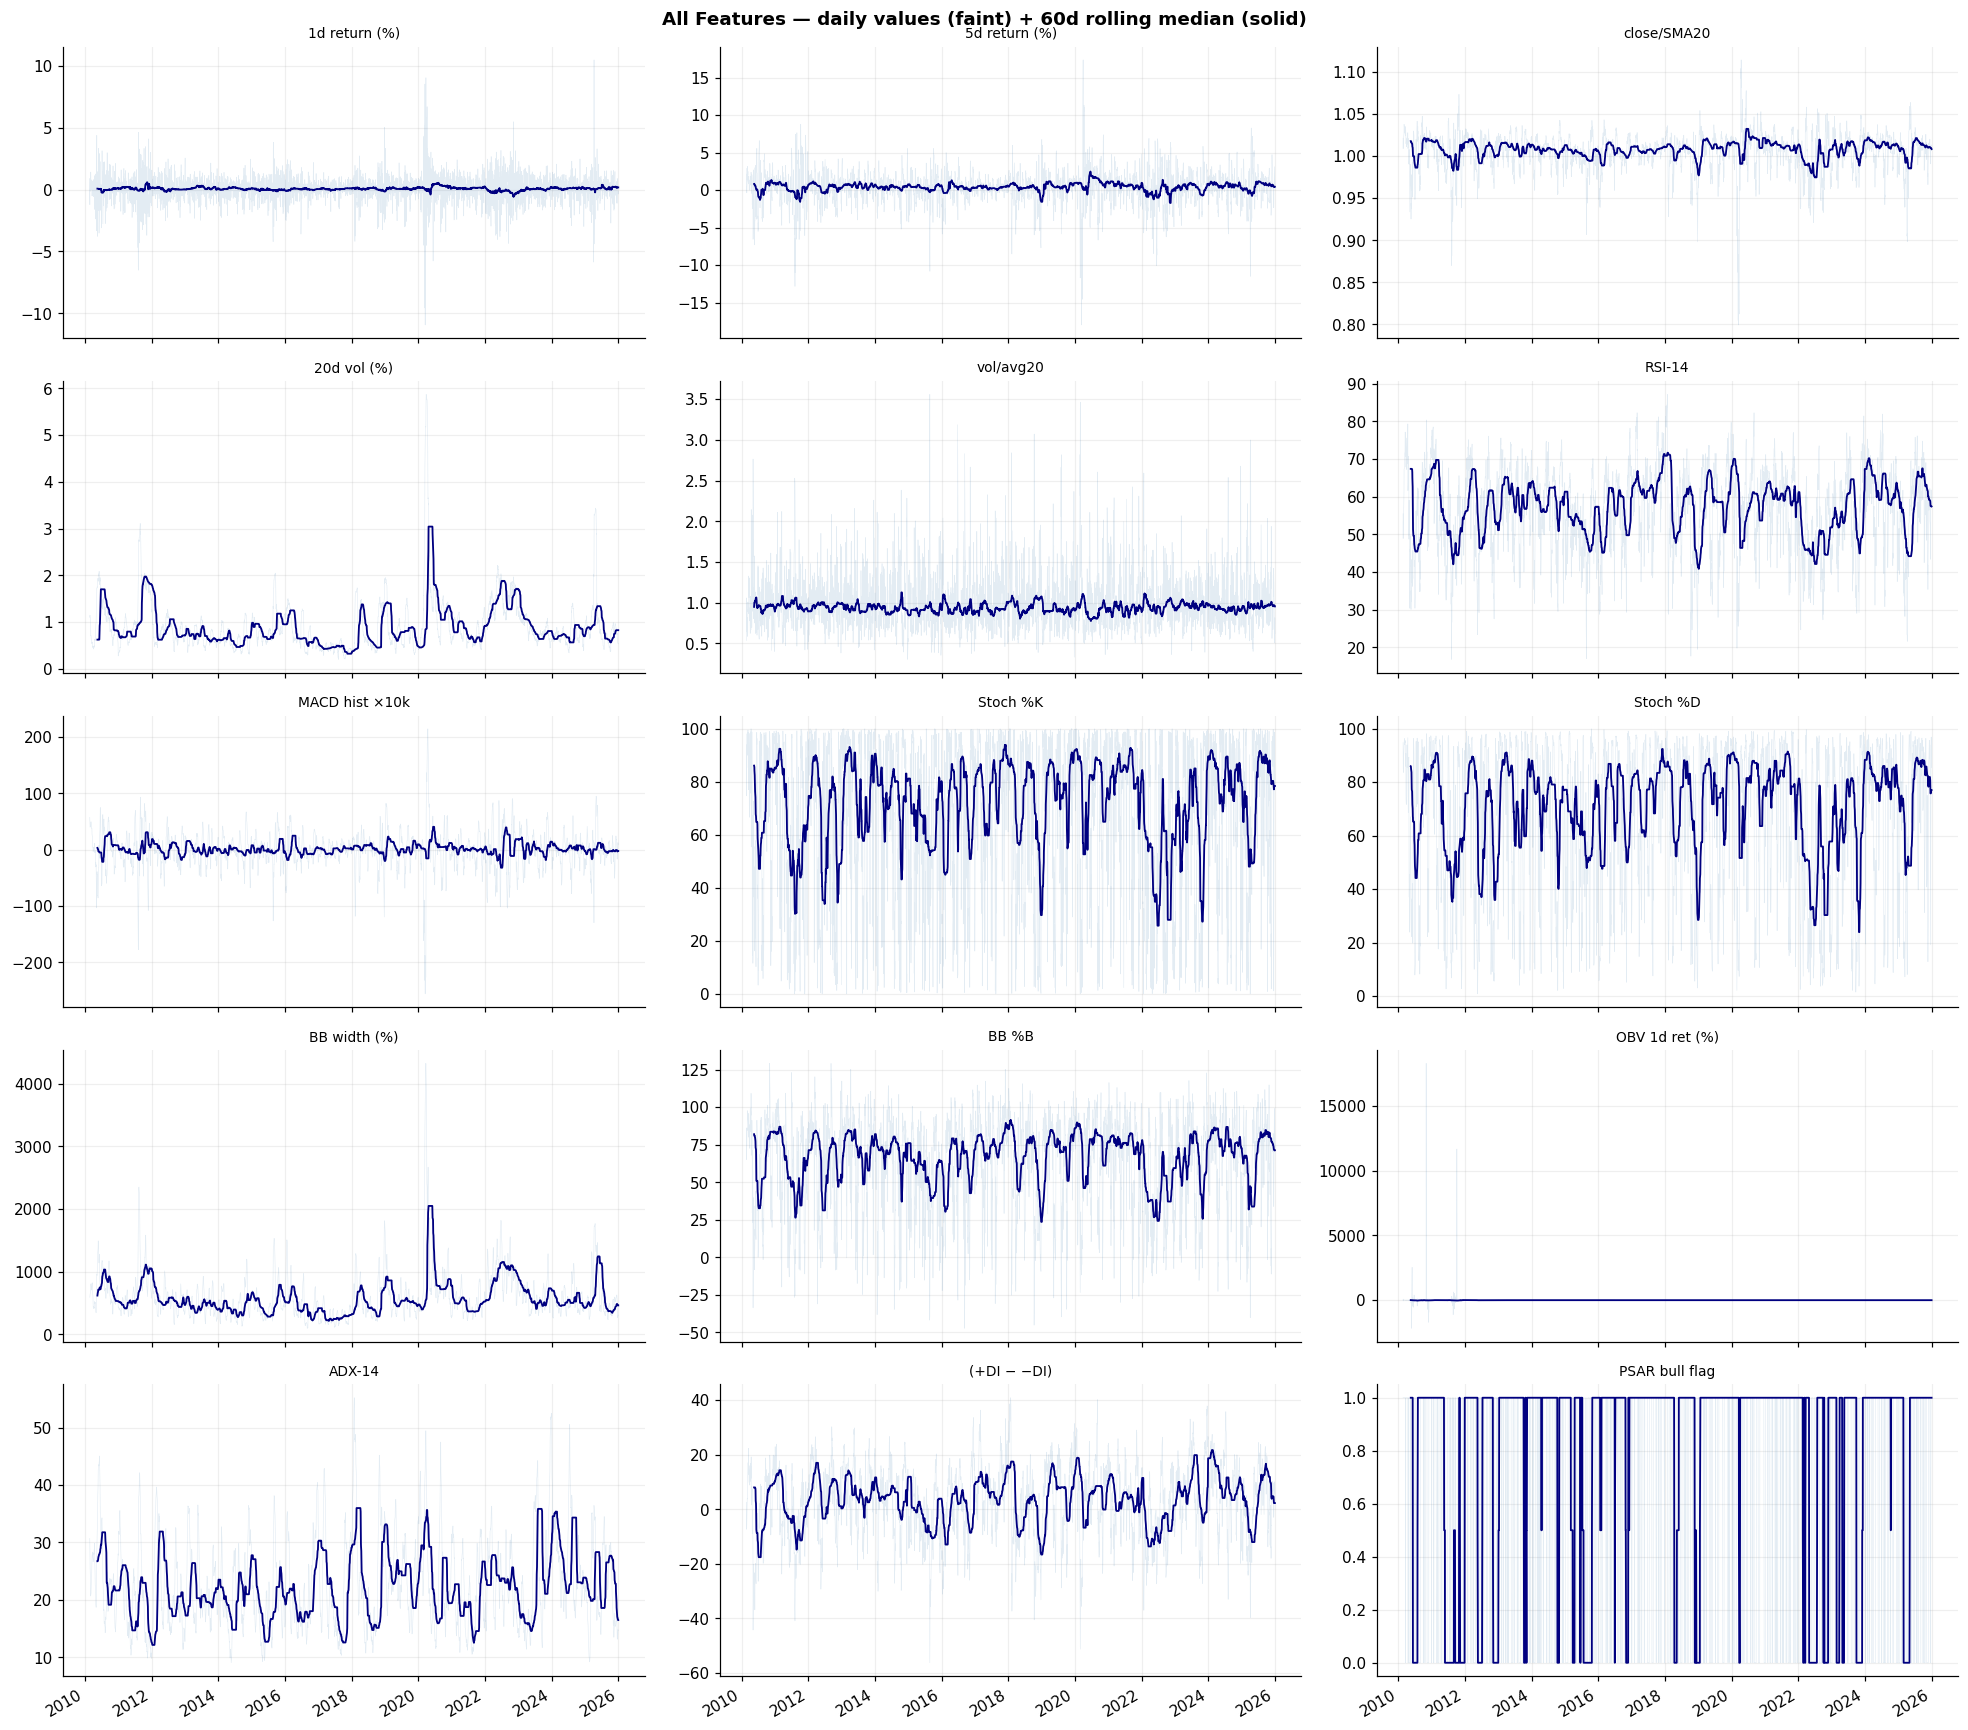

In [35]:
fig, axes = plt.subplots(5, 3, figsize=(18, 16), sharex=True)
fig.suptitle('All Features — daily values (faint) + 60d rolling median (solid)', fontsize=12, fontweight='bold')

for ax, col in zip(axes.flat, FEAT_COLS):
    ax.plot(df['date'], df[col], alpha=0.15, linewidth=0.4, color='steelblue')
    ax.plot(df['date'], df[col].rolling(60).median(), linewidth=1.2, color='navy')
    ax.set_title(LABELS[col], fontsize=9)
    ax.grid(alpha=0.2)

for ax in axes.flat[len(FEAT_COLS):]:
    ax.set_visible(False)

axes.flat[0].xaxis.set_major_locator(mdates.YearLocator(2))
axes.flat[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.autofmt_xdate(rotation=30, ha='right')
plt.tight_layout()
plt.show()

---
## 7 — Feature Correlation Heatmap

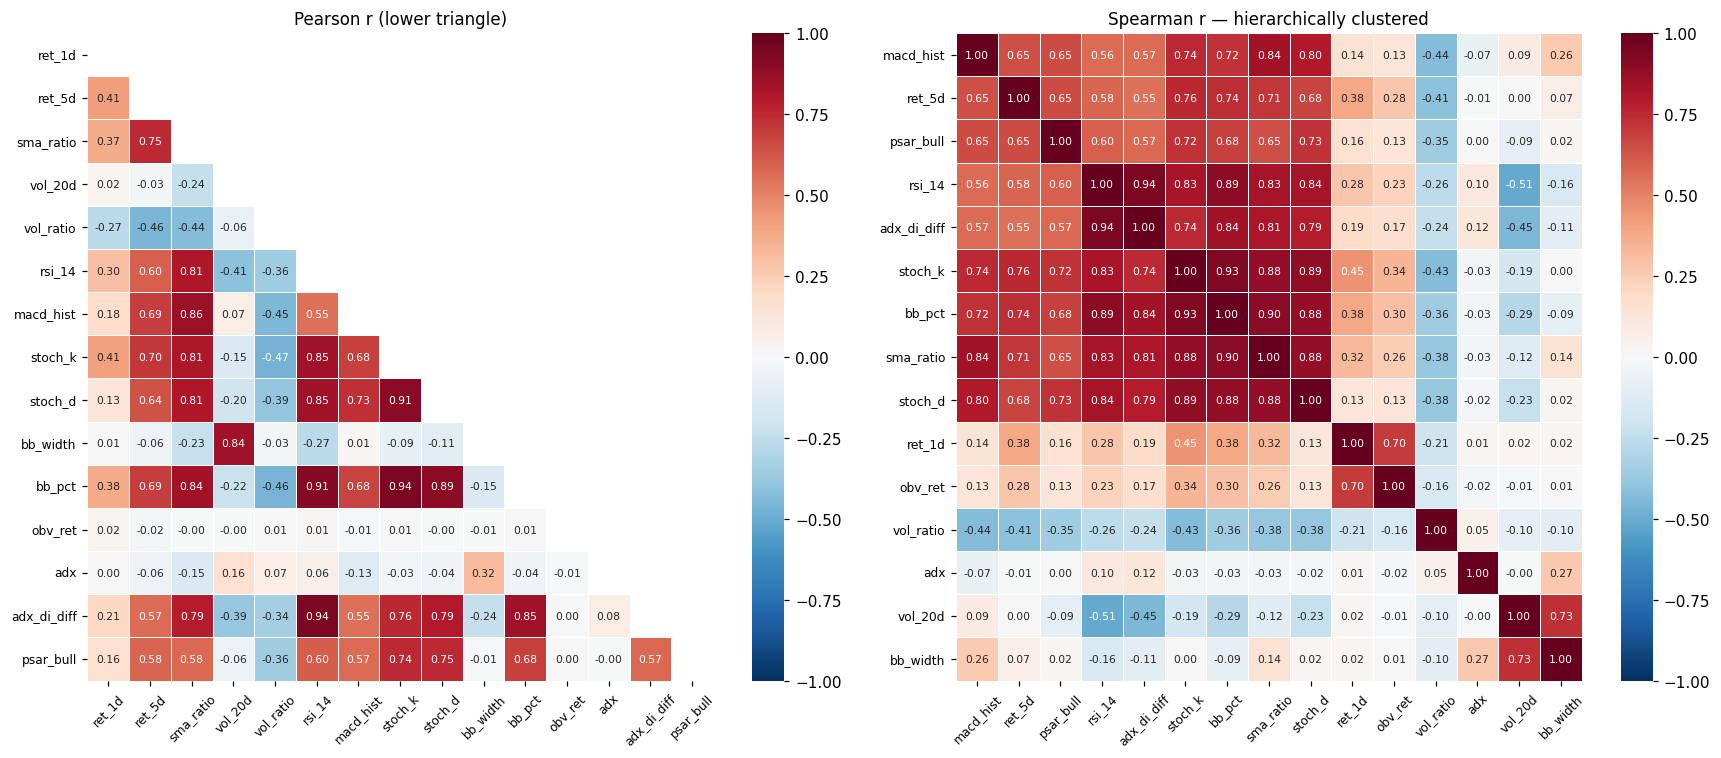

Strongly correlated pairs  |Pearson r| > 0.70:
  ret_5d          ↔ sma_ratio        r = +0.749
  ret_5d          ↔ stoch_k          r = +0.704
  sma_ratio       ↔ rsi_14           r = +0.810
  sma_ratio       ↔ macd_hist        r = +0.862
  sma_ratio       ↔ stoch_k          r = +0.808
  sma_ratio       ↔ stoch_d          r = +0.806
  sma_ratio       ↔ bb_pct           r = +0.839
  sma_ratio       ↔ adx_di_diff      r = +0.787
  vol_20d         ↔ bb_width         r = +0.844
  rsi_14          ↔ stoch_k          r = +0.850
  rsi_14          ↔ stoch_d          r = +0.847
  rsi_14          ↔ bb_pct           r = +0.906
  rsi_14          ↔ adx_di_diff      r = +0.941
  macd_hist       ↔ stoch_d          r = +0.732
  stoch_k         ↔ stoch_d          r = +0.906
  stoch_k         ↔ bb_pct           r = +0.939
  stoch_k         ↔ adx_di_diff      r = +0.757
  stoch_k         ↔ psar_bull        r = +0.744
  stoch_d         ↔ bb_pct           r = +0.891
  stoch_d         ↔ adx_di_diff      r = 

In [36]:
from scipy.cluster.hierarchy import linkage, leaves_list

corr    = df[FEAT_COLS].corr()
sp_corr = df[FEAT_COLS].corr(method='spearman')

# Hierarchical ordering for the clustered view
order  = leaves_list(linkage(sp_corr.values, method='ward'))
sp_ord = sp_corr.iloc[order, order]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', linewidths=0.4,
            cmap='RdBu_r', vmin=-1, vmax=1, center=0,
            annot_kws={'size': 7}, ax=axes[0])
axes[0].set_title('Pearson r (lower triangle)', fontsize=11)
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', rotation=0,  labelsize=8)

sns.heatmap(sp_ord, annot=True, fmt='.2f', linewidths=0.4,
            cmap='RdBu_r', vmin=-1, vmax=1, center=0,
            annot_kws={'size': 7}, ax=axes[1])
axes[1].set_title('Spearman r — hierarchically clustered', fontsize=11)
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1].tick_params(axis='y', rotation=0,  labelsize=8)

plt.tight_layout()
plt.show()

print("Strongly correlated pairs  |Pearson r| > 0.70:")
for i in range(len(FEAT_COLS)):
    for j in range(i+1, len(FEAT_COLS)):
        r = corr.iloc[i, j]
        if abs(r) > 0.70:
            print(f"  {FEAT_COLS[i]:15s} ↔ {FEAT_COLS[j]:15s}  r = {r:+.3f}")

---
## 8 — Predictive Power vs Forward Returns

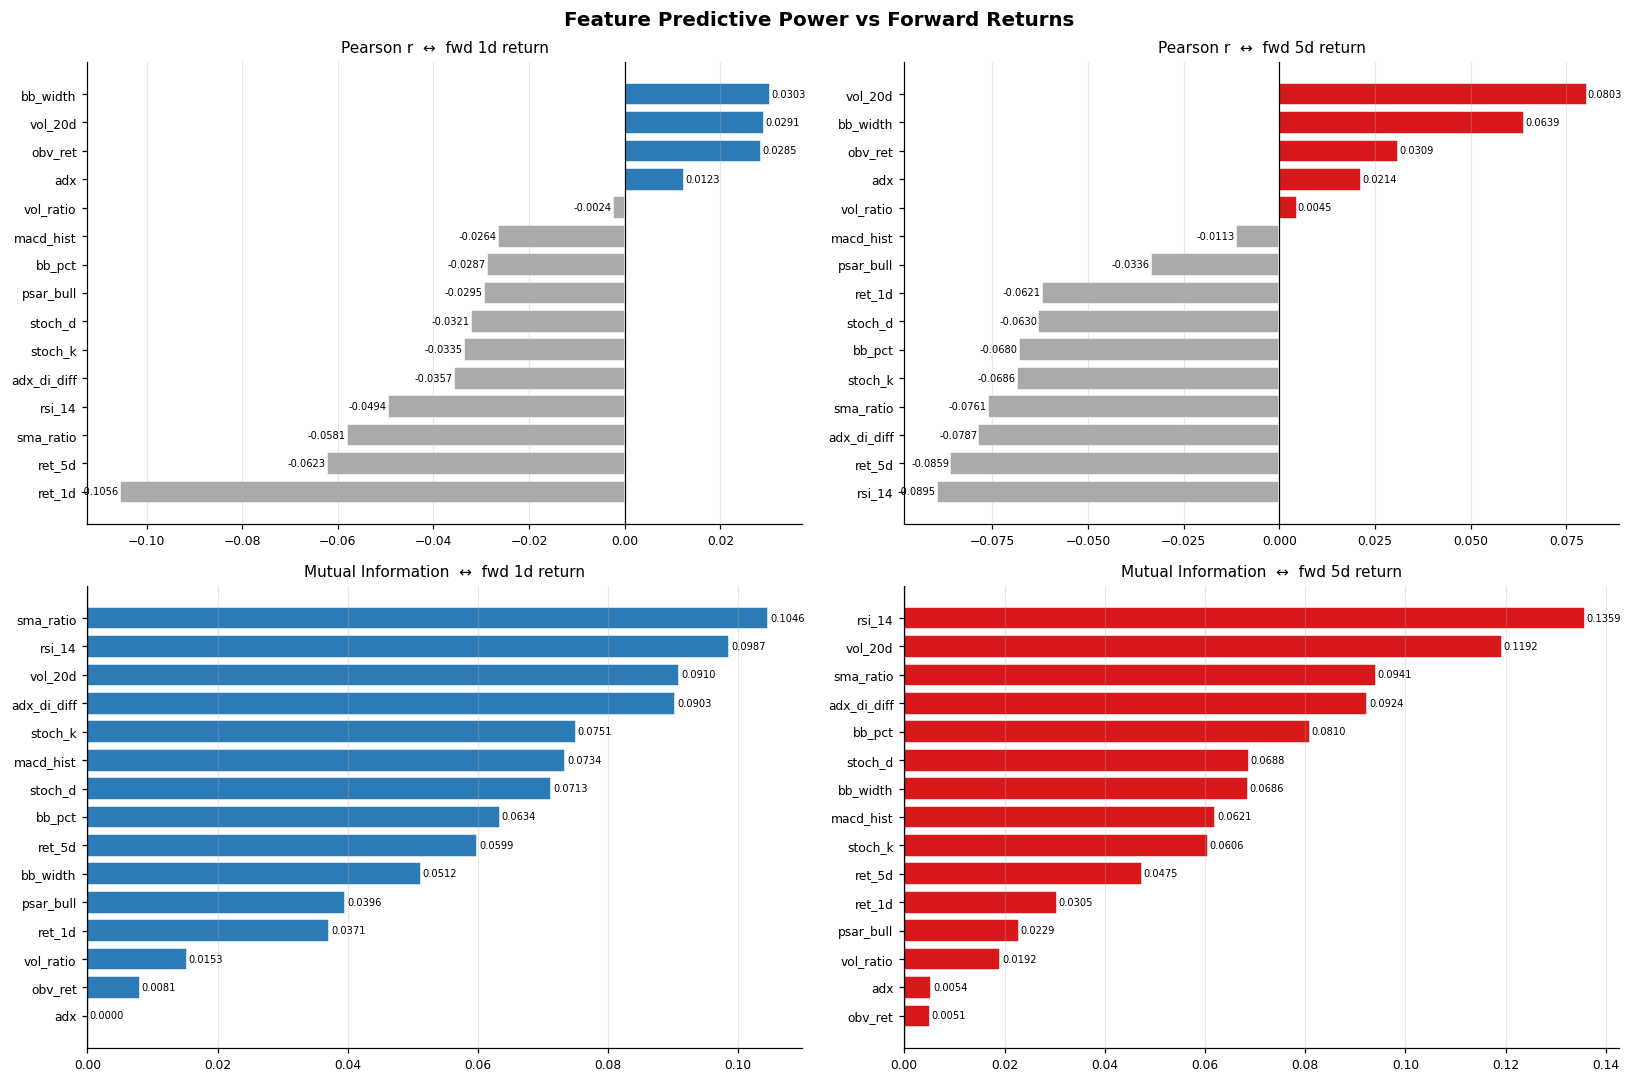


Predictive power summary (ranked by |Pearson| vs fwd 1d):
             Pearson_1d  Pearson_5d   MI_1d   MI_5d
ret_1d          -0.1056     -0.0621  0.0371  0.0305
ret_5d          -0.0623     -0.0859  0.0599  0.0475
sma_ratio       -0.0581     -0.0761  0.1046  0.0941
rsi_14          -0.0494     -0.0895  0.0987  0.1359
adx_di_diff     -0.0357     -0.0787  0.0903  0.0924
stoch_k         -0.0335     -0.0686  0.0751  0.0606
stoch_d         -0.0321     -0.0630  0.0713  0.0688
bb_width         0.0303      0.0639  0.0512  0.0686
psar_bull       -0.0295     -0.0336  0.0396  0.0229
vol_20d          0.0291      0.0803  0.0910  0.1192
bb_pct          -0.0287     -0.0680  0.0634  0.0810
obv_ret          0.0285      0.0309  0.0081  0.0051
macd_hist       -0.0264     -0.0113  0.0734  0.0621
adx              0.0123      0.0214  0.0000  0.0054
vol_ratio       -0.0024      0.0045  0.0153  0.0192


In [37]:
from sklearn.feature_selection import mutual_info_regression

df['fwd_1d'] = df['ret_1d'].shift(-1)
df['fwd_5d'] = df['ret_5d'].shift(-5)
clean = df[FEAT_COLS + ['fwd_1d','fwd_5d']].dropna()

pearson_1d = clean[FEAT_COLS].corrwith(clean['fwd_1d']).sort_values()
pearson_5d = clean[FEAT_COLS].corrwith(clean['fwd_5d']).sort_values()

X = clean[FEAT_COLS].values
mi_1d = pd.Series(mutual_info_regression(X, clean['fwd_1d'], random_state=42),
                  index=FEAT_COLS).sort_values()
mi_5d = pd.Series(mutual_info_regression(X, clean['fwd_5d'], random_state=42),
                  index=FEAT_COLS).sort_values()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Feature Predictive Power vs Forward Returns', fontsize=13, fontweight='bold')

for ax, data, title, c in [
    (axes[0,0], pearson_1d, 'Pearson r  ↔  fwd 1d return', '#2c7bb6'),
    (axes[0,1], pearson_5d, 'Pearson r  ↔  fwd 5d return', '#d7191c'),
    (axes[1,0], mi_1d,      'Mutual Information  ↔  fwd 1d return', '#2c7bb6'),
    (axes[1,1], mi_5d,      'Mutual Information  ↔  fwd 5d return', '#d7191c'),
]:
    colors = [c if v >= 0 else '#aaaaaa' for v in data]
    bars = ax.barh(data.index, data.values, color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(title, fontsize=10)
    ax.tick_params(labelsize=8)
    ax.grid(axis='x', alpha=0.3)
    for bar, v in zip(bars, data.values):
        ax.text(v + (0.0003 if v >= 0 else -0.0003), bar.get_y() + bar.get_height()/2,
                f'{v:.4f}', va='center', ha='left' if v >= 0 else 'right', fontsize=6.5)

plt.tight_layout()
plt.show()

print("\nPredictive power summary (ranked by |Pearson| vs fwd 1d):")
summary = pd.DataFrame({'Pearson_1d':pearson_1d,'Pearson_5d':pearson_5d,
                        'MI_1d':mi_1d,'MI_5d':mi_5d}).round(4)
print(summary.reindex(pearson_1d.abs().sort_values(ascending=False).index).to_string())

---
## 9 — Feature Behaviour by Volatility Regime

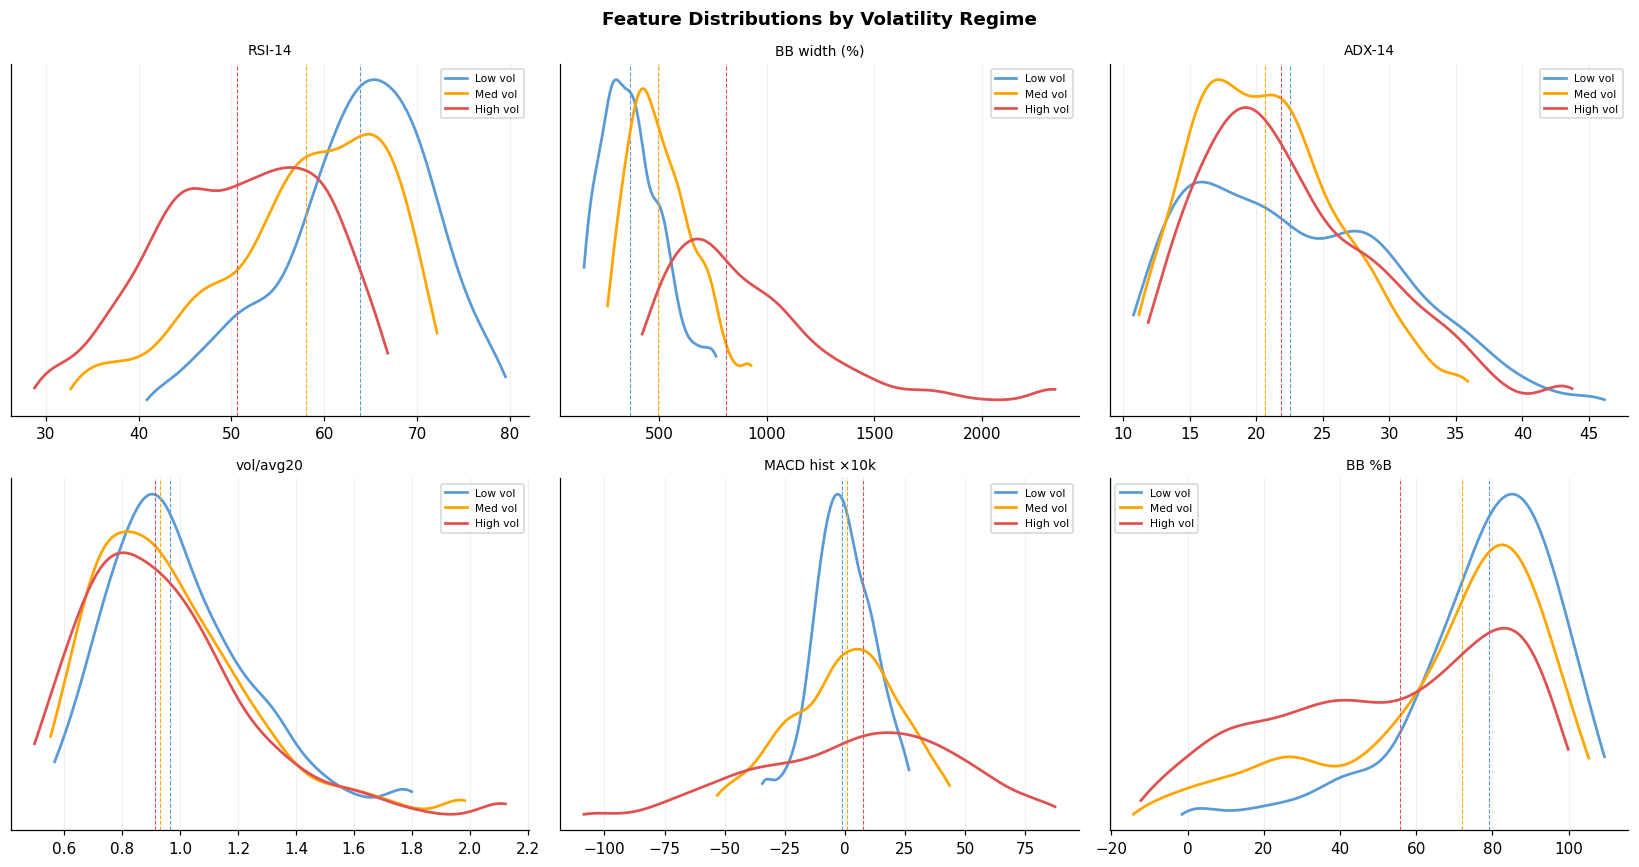

Median by regime:
          rsi_14  bb_width    adx  vol_ratio  macd_hist  bb_pct
regime                                                         
Low vol    63.90    363.97  22.54       0.97      -1.23   79.12
Med vol    57.99    493.04  20.61       0.93       0.77   71.97
High vol   50.60    810.79  21.83       0.91       7.68   55.84


In [38]:
df['regime'] = pd.qcut(df['vol_20d'], q=3, labels=['Low vol','Med vol','High vol'])
palette = {'Low vol':'#5b9bd5', 'Med vol':'#ffa500', 'High vol':'#e05252'}
regime_feats = ['rsi_14','bb_width','adx','vol_ratio','macd_hist','bb_pct']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Feature Distributions by Volatility Regime', fontsize=12, fontweight='bold')

for ax, col in zip(axes.flat, regime_feats):
    for regime, grp in df.groupby('regime'):
        d = grp[col].dropna()
        lo, hi = d.quantile(0.02), d.quantile(0.98)
        d = d.clip(lo, hi)
        kde_x = np.linspace(lo, hi, 200)
        ax.plot(kde_x, stats.gaussian_kde(d)(kde_x),
                label=str(regime), color=palette[str(regime)], linewidth=1.8)
        ax.axvline(d.median(), color=palette[str(regime)], linewidth=0.7, linestyle='--')
    ax.set_title(LABELS[col], fontsize=9)
    ax.set_yticks([]); ax.grid(alpha=0.2); ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

print("Median by regime:")
print(df.groupby('regime')[regime_feats].median().round(2).to_string())

---
## 10 — Z-Score Normalisation & Train / Val / Test Split Statistics

Split sizes:
  Train: 2988 rows  2010-02-22 → 2021-12-31
  Val  :  501 rows  2022-01-03 → 2023-12-29
  Test :  501 rows  2024-01-02 → 2025-12-30

Normalised train set — mean & std (should be ~0 and ~1):
             mean  std
ret_1d       -0.0  1.0
ret_5d        0.0  1.0
sma_ratio    -0.0  1.0
vol_20d      -0.0  1.0
vol_ratio    -0.0  1.0
rsi_14       -0.0  1.0
macd_hist     0.0  1.0
stoch_k      -0.0  1.0
stoch_d       0.0  1.0
bb_width     -0.0  1.0
bb_pct        0.0  1.0
obv_ret       0.0  1.0
adx          -0.0  1.0
adx_di_diff  -0.0  1.0
psar_bull    -0.0  1.0


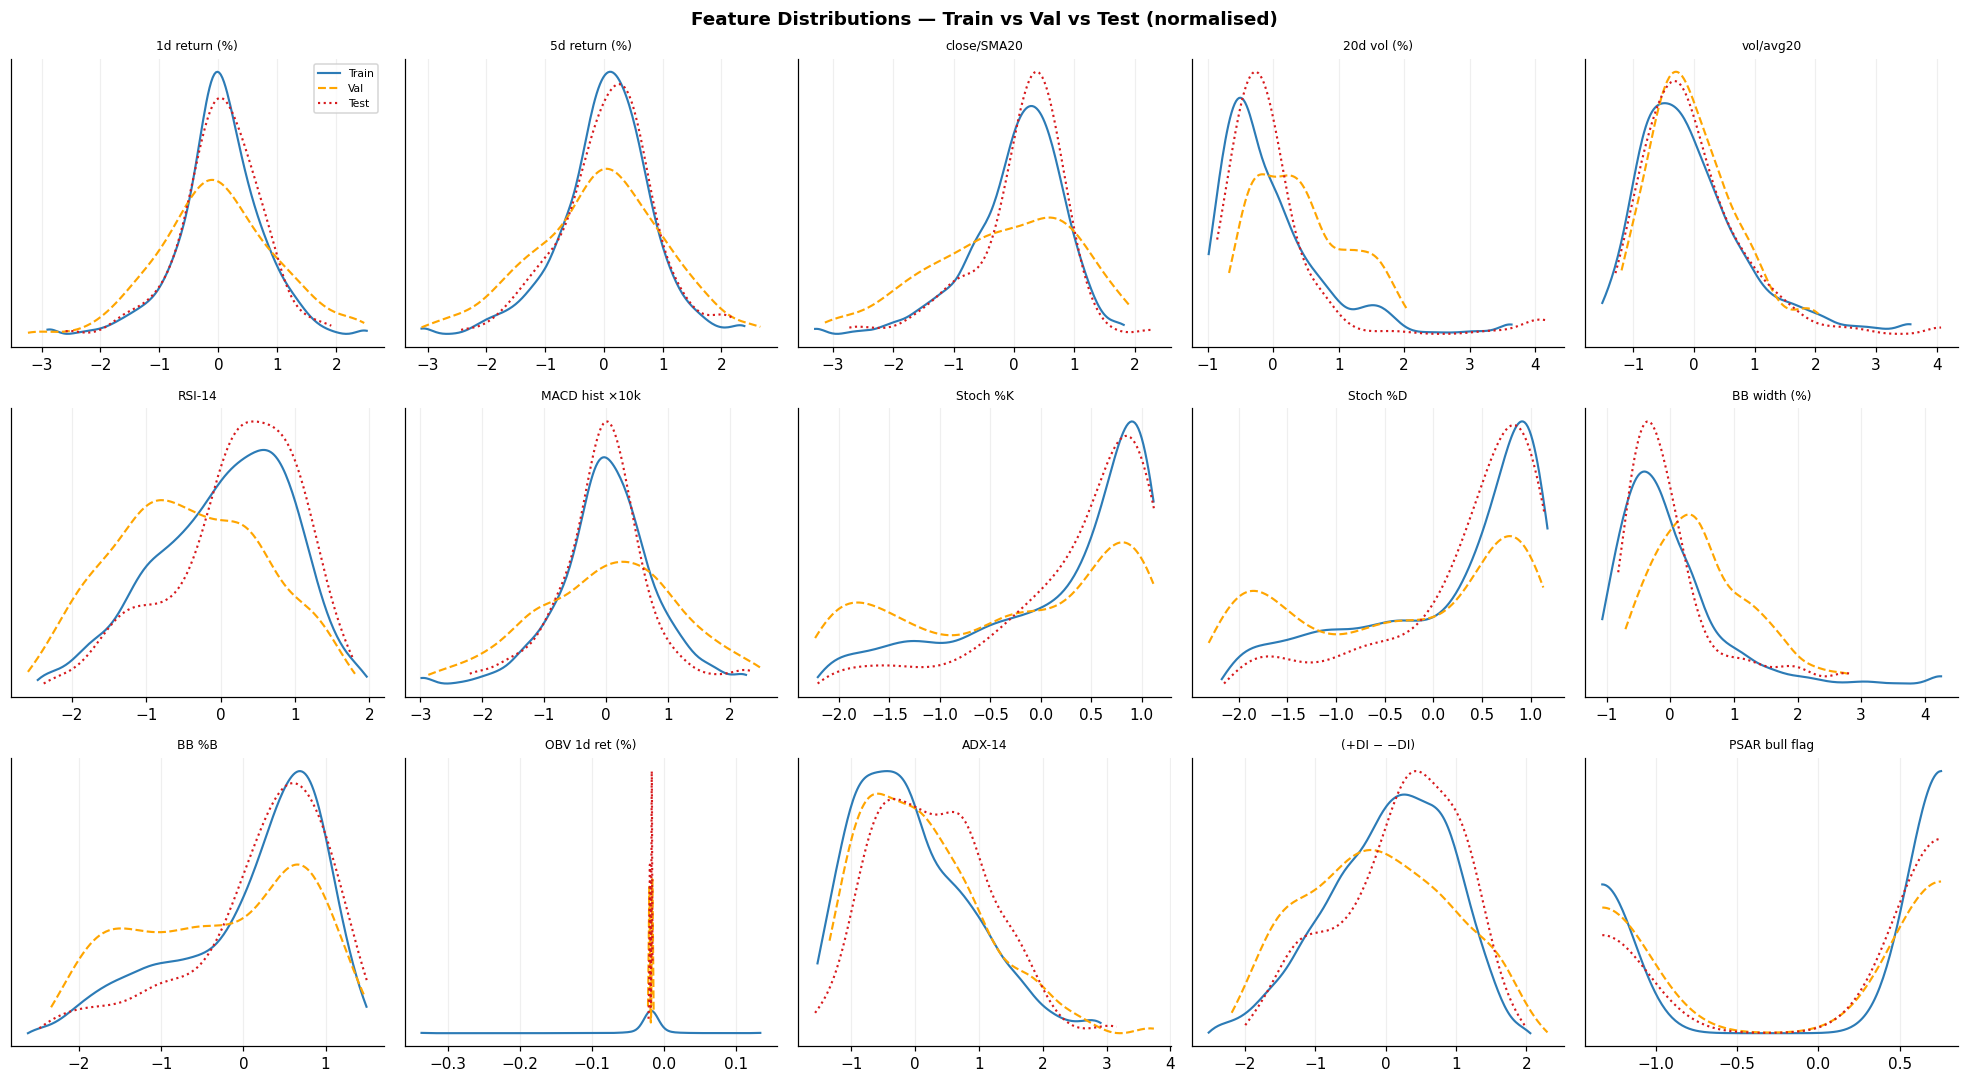

In [39]:
# Load the already-normalised processed splits
train = pd.read_csv('../data/processed/SPY/train.csv', parse_dates=['date'])
val   = pd.read_csv('../data/processed/SPY/val.csv',   parse_dates=['date'])
test  = pd.read_csv('../data/processed/SPY/test.csv',  parse_dates=['date'])

print("Split sizes:")
for name, d in [('Train', train), ('Val', val), ('Test', test)]:
    print(f"  {name:5s}: {len(d):4d} rows  {d['date'].min().date()} → {d['date'].max().date()}")

# Confirm scaler (mean≈0, std≈1 on training set for all features)
print("\nNormalised train set — mean & std (should be ~0 and ~1):")
norm_stats = pd.DataFrame({'mean': train[FEAT_COLS].mean(),
                           'std':  train[FEAT_COLS].std()}).round(3)
print(norm_stats.to_string())

# Distribution overlap: compare train vs val vs test for each feature
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
fig.suptitle('Feature Distributions — Train vs Val vs Test (normalised)', fontsize=12, fontweight='bold')
split_styles = [('Train', train, '#2c7bb6', '-'),
                ('Val',   val,   '#ffa500', '--'),
                ('Test',  test,  '#d7191c', ':')]

for ax, col in zip(axes.flat, FEAT_COLS):
    for name, d, c, ls in split_styles:
        vals = d[col].dropna()
        lo, hi = vals.quantile(0.01), vals.quantile(0.99)
        vals = vals.clip(lo, hi)
        if len(vals) > 5:
            kde_x = np.linspace(vals.min(), vals.max(), 200)
            ax.plot(kde_x, stats.gaussian_kde(vals)(kde_x),
                    color=c, linestyle=ls, linewidth=1.4, label=name)
    ax.set_title(LABELS[col], fontsize=8)
    ax.set_yticks([])
    ax.grid(alpha=0.2)

axes.flat[0].legend(fontsize=7)
for ax in axes.flat[len(FEAT_COLS):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

---
## 11 — Feature Importance: LightGBM + Permutation + SHAP

Train a LightGBM regressor on the **training split** to predict next-day return, then evaluate three complementary importance views on the **validation set**:
- **LightGBM native** (split / gain) — fast, but biased towards high-cardinality features  
- **Permutation importance** — model-agnostic, measures actual validation score drop  
- **SHAP values** — explains each prediction; summary + dependence plots

In [40]:
import lightgbm as lgb
import shap
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score

# ── Load normalised splits (features already z-scored) ────────────────────────
train = pd.read_csv('../data/processed/SPY/train.csv', parse_dates=['date'])
val   = pd.read_csv('../data/processed/SPY/val.csv',   parse_dates=['date'])

FEAT_COLS = ['ret_1d','ret_5d','sma_ratio','vol_20d','vol_ratio',
             'rsi_14','macd_hist','stoch_k','stoch_d',
             'bb_width','bb_pct','obv_ret','adx','adx_di_diff','psar_bull']

# Target: next-day return (shift -1 within each split to avoid leakage)
train = train.copy(); train['target'] = train['ret_1d'].shift(-1)
val   = val.copy();   val['target']   = val['ret_1d'].shift(-1)
train = train.dropna(subset=FEAT_COLS + ['target'])
val   = val.dropna(subset=FEAT_COLS + ['target'])

X_train, y_train = train[FEAT_COLS].values, train['target'].values
X_val,   y_val   = val[FEAT_COLS].values,   val['target'].values

# ── Train LightGBM ─────────────────────────────────────────────────────────────
params = dict(
    objective='regression', metric='rmse',
    n_estimators=500, learning_rate=0.05,
    num_leaves=31, min_child_samples=20,
    feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
    verbose=-1, random_state=42,
)
model = lgb.LGBMRegressor(**params)
model.fit(X_train, y_train,
          eval_set=[(X_val, y_val)],
          callbacks=[lgb.early_stopping(50, verbose=False),
                     lgb.log_evaluation(period=-1)])

y_pred = model.predict(X_val)
r2  = r2_score(y_val, y_pred)
print(f"Val R²  : {r2:.4f}")
print(f"Val RMSE: {np.sqrt(np.mean((y_pred - y_val)**2)):.4f}%")
print(f"Baseline (predict mean) RMSE: {np.std(y_val):.4f}%")
print(f"\nNote: predicting daily returns is inherently noisy — "
      f"R² ~ 0 is expected. Importance ranks still reveal signal structure.")

Val R²  : 0.0067
Val RMSE: 1.1480%
Baseline (predict mean) RMSE: 1.1519%

Note: predicting daily returns is inherently noisy — R² ~ 0 is expected. Importance ranks still reveal signal structure.


### 11a — LightGBM Native Importance (split count & gain)

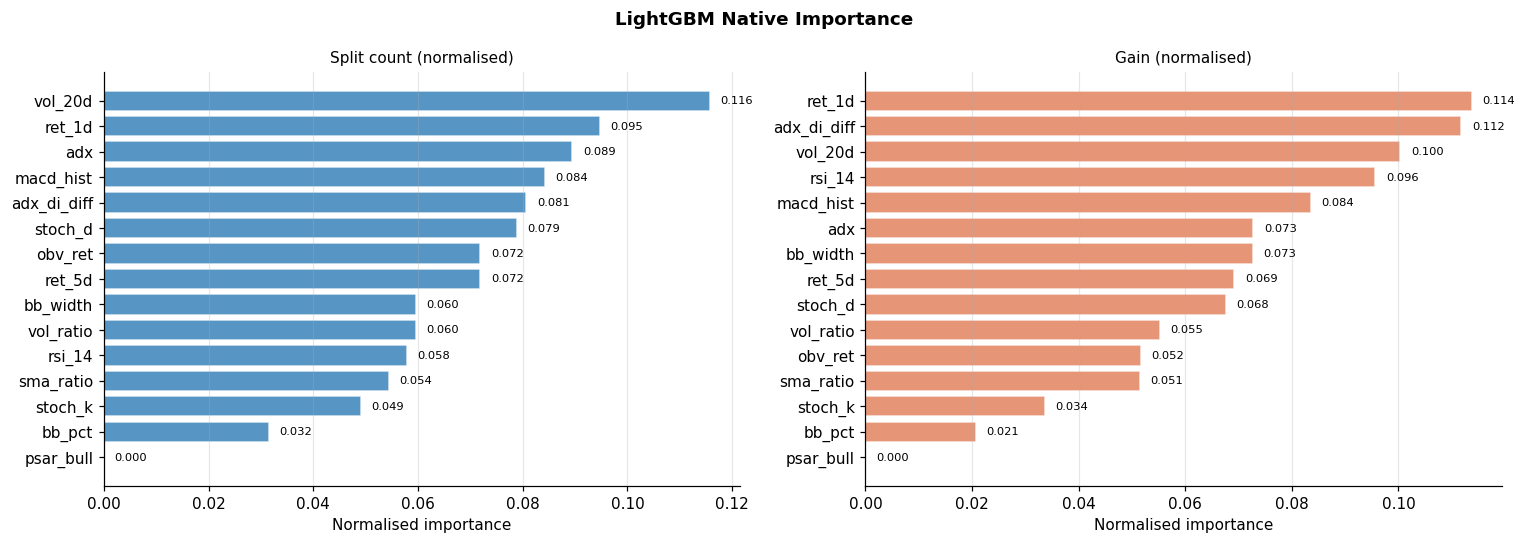

             Split (norm)  Gain (norm)  rank_split  rank_gain
ret_1d             0.0947       0.1138           2          1
adx_di_diff        0.0807       0.1118           5          2
vol_20d            0.1158       0.1003           1          3
rsi_14             0.0579       0.0957          11          4
macd_hist          0.0842       0.0836           4          5
adx                0.0895       0.0728           3          6
bb_width           0.0596       0.0727           9          7
ret_5d             0.0719       0.0692           7          8
stoch_d            0.0789       0.0676           6          9
vol_ratio          0.0596       0.0552           9         10
obv_ret            0.0719       0.0516           7         11
sma_ratio          0.0544       0.0514          12         12
stoch_k            0.0491       0.0336          13         13
bb_pct             0.0316       0.0207          14         14
psar_bull          0.0000       0.0000          15         15


In [41]:
imp_split = pd.Series(model.feature_importances_,           index=FEAT_COLS)
imp_gain  = pd.Series(model.booster_.feature_importance('gain'), index=FEAT_COLS)

# Normalise to [0, 1]
imp_split_n = imp_split / imp_split.sum()
imp_gain_n  = imp_gain  / imp_gain.sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LightGBM Native Importance', fontsize=12, fontweight='bold')

for ax, imp, title, c in [
    (axes[0], imp_split_n.sort_values(), 'Split count (normalised)', '#2c7bb6'),
    (axes[1], imp_gain_n.sort_values(),  'Gain (normalised)',        '#e07b54'),
]:
    bars = ax.barh(imp.index, imp.values, color=c, alpha=0.8, edgecolor='white')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Normalised importance')
    ax.grid(axis='x', alpha=0.3)
    for bar, v in zip(bars, imp.values):
        ax.text(v + 0.002, bar.get_y() + bar.get_height()/2,
                f'{v:.3f}', va='center', fontsize=7.5)

plt.tight_layout()
plt.show()

# Side-by-side table
native_df = pd.DataFrame({'Split (norm)': imp_split_n, 'Gain (norm)': imp_gain_n})
native_df['rank_split'] = native_df['Split (norm)'].rank(ascending=False).astype(int)
native_df['rank_gain']  = native_df['Gain (norm)'].rank(ascending=False).astype(int)
print(native_df.sort_values('Gain (norm)', ascending=False).round(4).to_string())

### 11b — Permutation Importance (validation set)

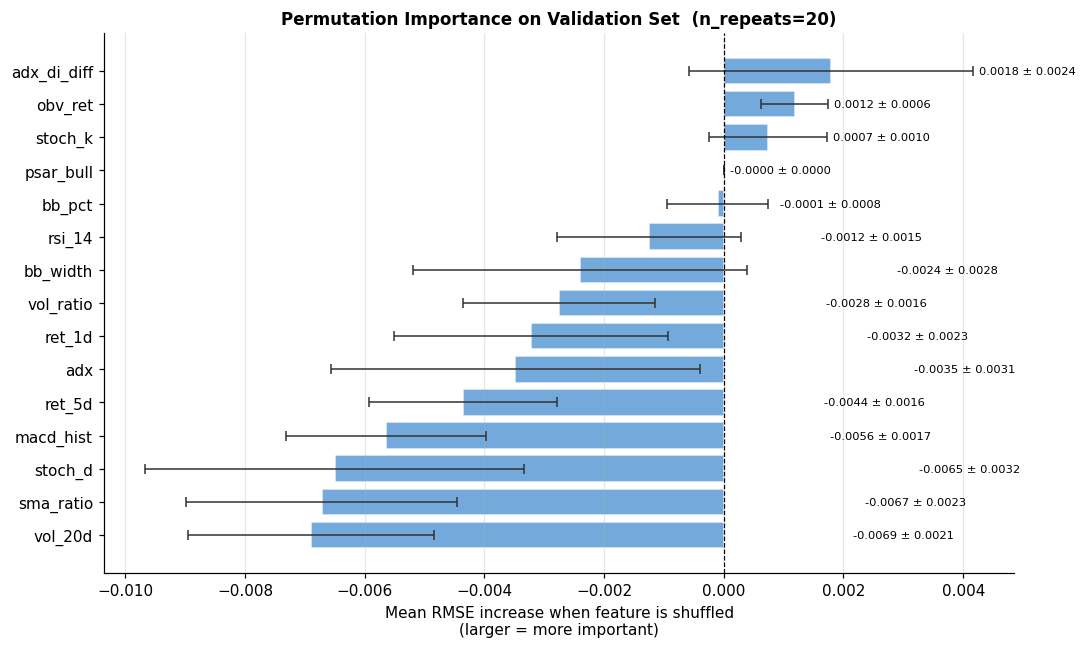


Permutation importance ranking (validation set):
                mean      std
adx_di_diff  0.00179  0.00237
obv_ret      0.00118  0.00056
stoch_k      0.00074  0.00099
psar_bull   -0.00000  0.00000
bb_pct      -0.00010  0.00085
rsi_14      -0.00125  0.00153
bb_width    -0.00240  0.00279
vol_ratio   -0.00276  0.00160
ret_1d      -0.00322  0.00229
adx         -0.00348  0.00308
ret_5d      -0.00436  0.00157
macd_hist   -0.00565  0.00167
stoch_d     -0.00650  0.00316
sma_ratio   -0.00672  0.00226
vol_20d     -0.00689  0.00205


In [42]:
perm = permutation_importance(
    model, X_val, y_val,
    n_repeats=20, random_state=42, scoring='neg_root_mean_squared_error'
)

perm_mean = pd.Series(-perm.importances_mean, index=FEAT_COLS)  # flip: less negative = more important
perm_std  = pd.Series(perm.importances_std,   index=FEAT_COLS)
perm_df   = pd.DataFrame({'mean': perm_mean, 'std': perm_std}).sort_values('mean', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(perm_df.index, perm_df['mean'], xerr=perm_df['std'],
        color='#5b9bd5', alpha=0.85, edgecolor='white',
        error_kw=dict(ecolor='#333', capsize=3, linewidth=1))
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Mean RMSE increase when feature is shuffled\n(larger = more important)')
ax.set_title('Permutation Importance on Validation Set  (n_repeats=20)', fontsize=11, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

for i, (feat, row) in enumerate(perm_df.iterrows()):
    ax.text(max(row['mean'], 0) + row['std'] + 0.0001, i,
            f"{row['mean']:.4f} ± {row['std']:.4f}", va='center', fontsize=7.5)

plt.tight_layout()
plt.show()

print("\nPermutation importance ranking (validation set):")
print(perm_df[::-1].round(5).to_string())

### 11c — SHAP Values (validation set)

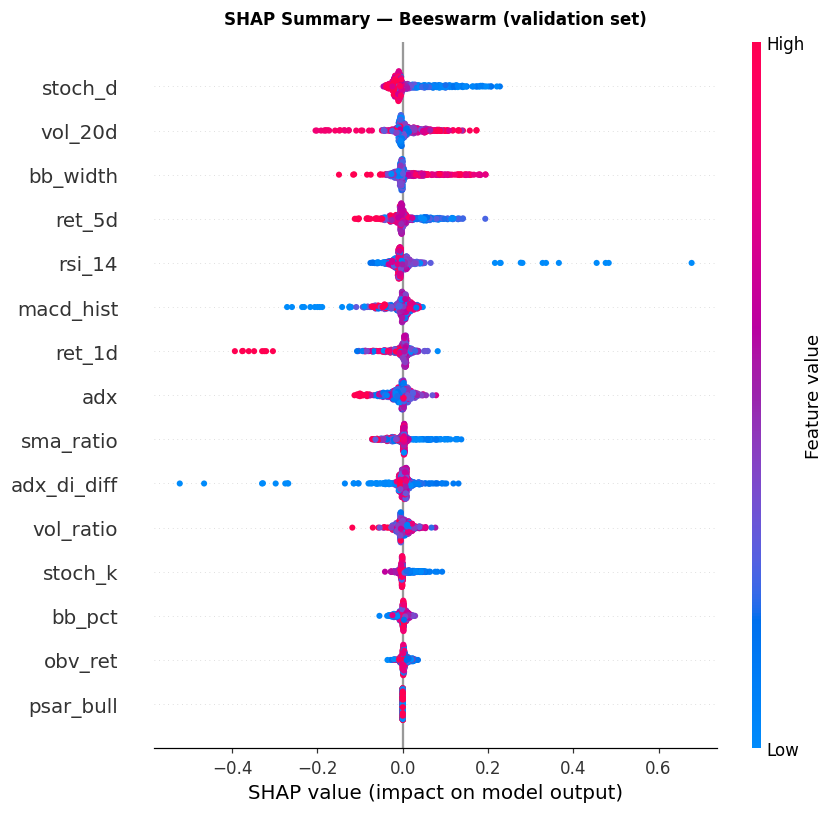

In [43]:
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_val)   # shape: (n_val, n_features)
shap_df     = pd.DataFrame(shap_values, columns=FEAT_COLS)

# ── Summary beeswarm plot ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values, X_val, feature_names=FEAT_COLS,
                  plot_type='dot', show=False, max_display=15)
plt.title('SHAP Summary — Beeswarm (validation set)', fontsize=11, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

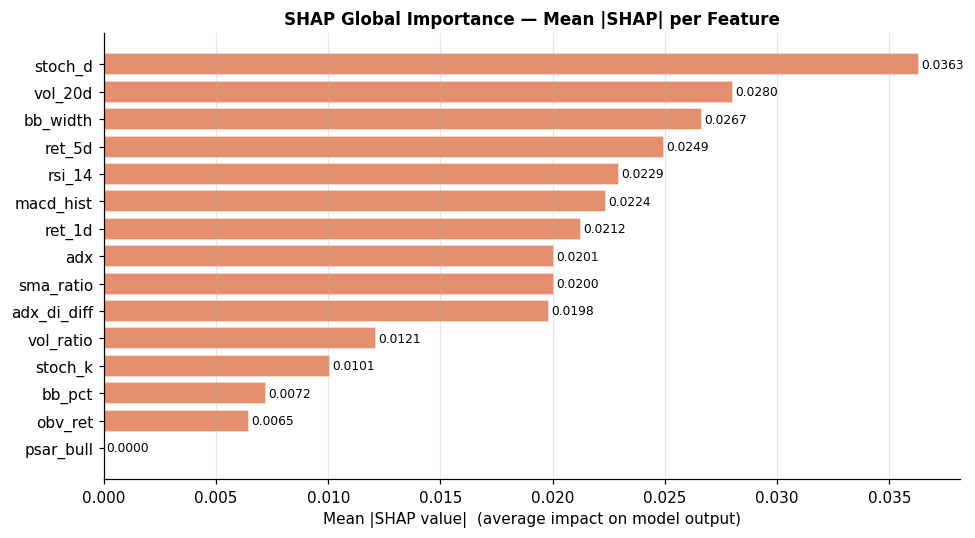

In [44]:
# ── Mean |SHAP| bar chart ─────────────────────────────────────────────────────
mean_abs_shap = shap_df.abs().mean().sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(mean_abs_shap.index, mean_abs_shap.values,
               color='#e07b54', alpha=0.85, edgecolor='white')
ax.set_xlabel('Mean |SHAP value|  (average impact on model output)')
ax.set_title('SHAP Global Importance — Mean |SHAP| per Feature', fontsize=11, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
for bar, v in zip(bars, mean_abs_shap.values):
    ax.text(v + 0.0001, bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

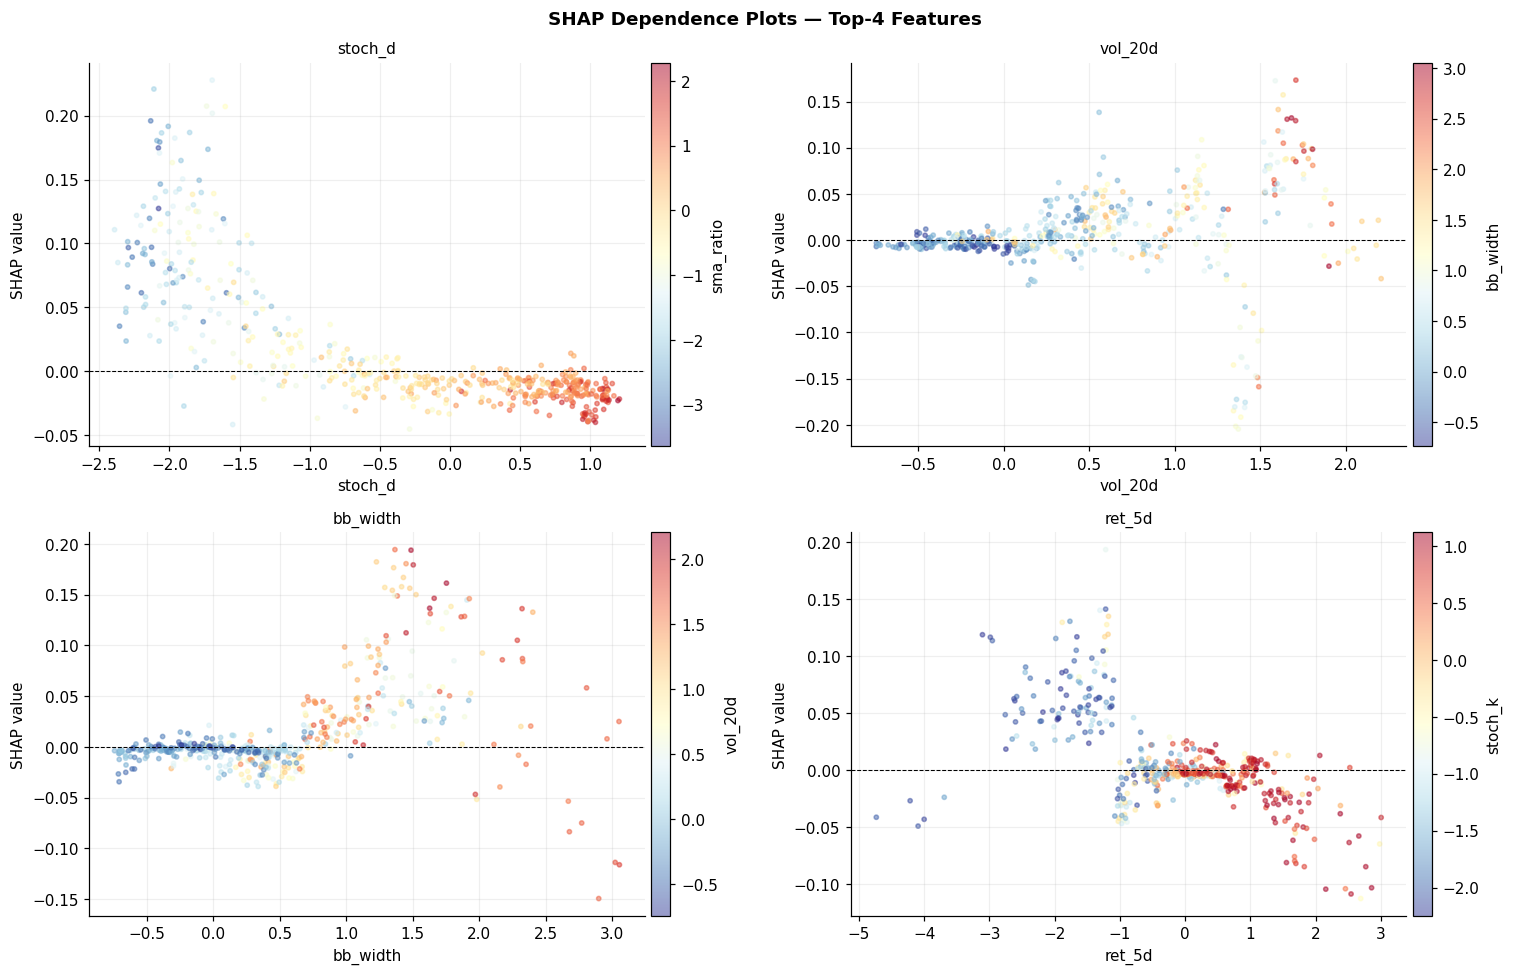

In [45]:
# ── SHAP dependence plots for top-4 features ─────────────────────────────────
top4 = mean_abs_shap.nlargest(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('SHAP Dependence Plots — Top-4 Features', fontsize=12, fontweight='bold')

for ax, feat in zip(axes.flat, top4):
    fi      = FEAT_COLS.index(feat)
    x_vals  = X_val[:, fi]
    s_vals  = shap_values[:, fi]

    # colour points by the most-interacting feature (auto-detected by SHAP)
    interact_fi = np.argmax([
        np.corrcoef(X_val[:, j], s_vals)[0, 1]**2
        for j in range(len(FEAT_COLS)) if j != fi
    ])
    if interact_fi >= fi:
        interact_fi += 1
    color_vals = X_val[:, interact_fi]

    sc = ax.scatter(x_vals, s_vals, c=color_vals, cmap='RdYlBu_r',
                    s=8, alpha=0.5, rasterized=True)
    plt.colorbar(sc, ax=ax, label=FEAT_COLS[interact_fi], pad=0.01)
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
    ax.set_xlabel(feat)
    ax.set_ylabel('SHAP value')
    ax.set_title(f'{feat}', fontsize=10)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

Feature importance consensus ranking (lower = more important):

             LGBM gain rank  Permutation rank  SHAP |mean| rank  consensus
adx_di_diff               2                 1                10          1
rsi_14                    4                 6                 5          2
bb_width                  7                 7                 3          3
ret_1d                    1                 9                 7          3
vol_20d                   3                15                 2          5
macd_hist                 5                12                 6          7
ret_5d                    8                11                 4          7
stoch_d                   9                13                 1          7
adx                       6                10                 8          9
obv_ret                  11                 2                14         10
stoch_k                  13                 3                12         11
vol_ratio                10         

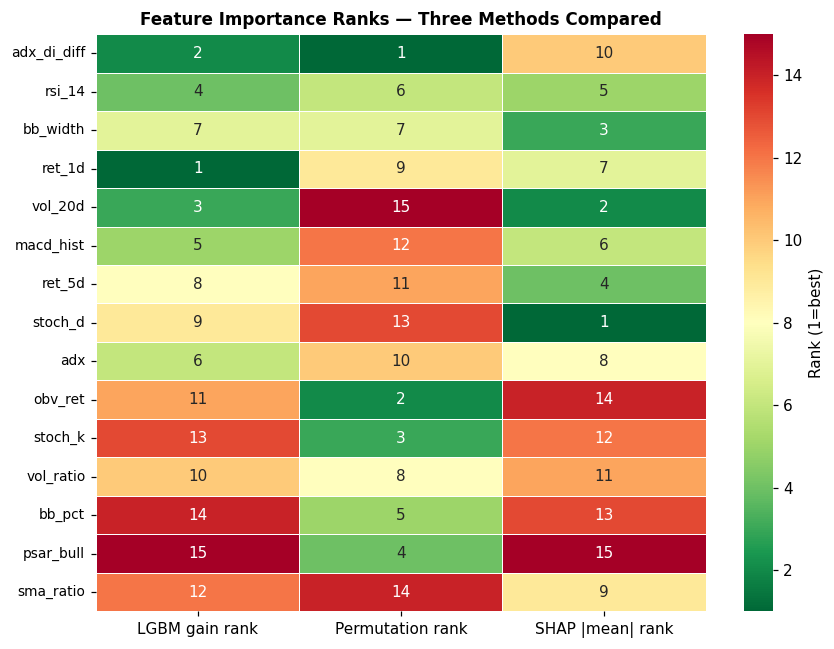

In [46]:
# ── Consolidated ranking: all three methods side-by-side ─────────────────────
rank_df = pd.DataFrame({
    'LGBM gain rank':        imp_gain_n.rank(ascending=False).astype(int),
    'Permutation rank':      perm_mean.rank(ascending=False).astype(int),
    'SHAP |mean| rank':      mean_abs_shap.rank(ascending=False).astype(int),
})
rank_df['mean rank'] = rank_df.mean(axis=1)
rank_df = rank_df.sort_values('mean rank')
rank_df['consensus'] = rank_df['mean rank'].rank().astype(int)

print("Feature importance consensus ranking (lower = more important):\n")
print(rank_df.drop(columns='mean rank').to_string())

# ── Heatmap of ranks ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
heat_data = rank_df[['LGBM gain rank','Permutation rank','SHAP |mean| rank']]
sns.heatmap(heat_data, annot=True, fmt='d', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Rank (1=best)'})
ax.set_title('Feature Importance Ranks — Three Methods Compared', fontsize=11, fontweight='bold')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.show()